In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
"""Definimos las direcciones de los archivos"""

dirl1e13 = "./data/q5050/var_lambda/lambda_1e-13/"
dirl1e14 = "./data/q5050/var_lambda/lambda_1e-14/"
dirl1e15 = "./data/q5050/var_lambda/lambda_1e-15/"
dirl2e14 = "./data/q5050/var_lambda/lambda_2e-14/"
dirl2e15 = "./data/q5050/var_lambda/lambda_2e-15/"
dirl5e14 = "./data/q5050/var_lambda/lambda_5e-14/"
dirl5e15 = "./data/q5050/var_lambda/lambda_5e-15/"
dirl7e14 = "./data/q5050/var_lambda/lambda_7e-14/"
dirl7e15 = "./data/q5050/var_lambda/lambda_7e-15/"

q = 5050

# Buscamos las bandas de resonancia

In [3]:
# Función para armarse la matriz de monodromía y calcular los coeficientes de Floquet
def mu_lphi4(k, q, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, q):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi**3
        chi_ddot_k = - (k**2 + q * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-4, args=(k, q))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-4, args=(k, q))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[2], y_final2[2]],
        [y_final1[3], y_final2[3]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0
    
# Función para calcular el período de oscilación del inflatón
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

In [4]:
"""Parámetros"""

phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)

y0 = (phi0, phi_dot0)
E = 0.5 * phi_dot0**2 + 0.25 * phi0**4
ks = np.logspace(-1, 1, 1000)
Tosc = oscilation(E)

In [5]:
muq = np.zeros(len(ks), dtype=complex)
muq3 = np.zeros(len(ks), dtype=complex)

for j, k in enumerate(tqdm(ks)):
    muq[j] = mu_lphi4(k, q, y0, Tosc)
    muq3[j] = mu_lphi4(k, 3, y0, Tosc) # Para ver el inflatón

100%|██████████| 1000/1000 [02:20<00:00,  7.11it/s]


In [6]:
#Calculamos el máximo y el ancho de cada banda de inestabilidad
max_muq = np.max(np.real(muq))
k_maxq = ks[np.argmax(np.real(muq))]
k_deltaq = ks[np.where(np.real(muq) >= max_muq/2)[0]]

max_muq3 = np.max(np.real(muq3))
k_maxq3 = ks[np.argmax(np.real(muq3))]
k_deltaq3 = ks[np.where(np.real(muq3) >= max_muq3/2)[0]]

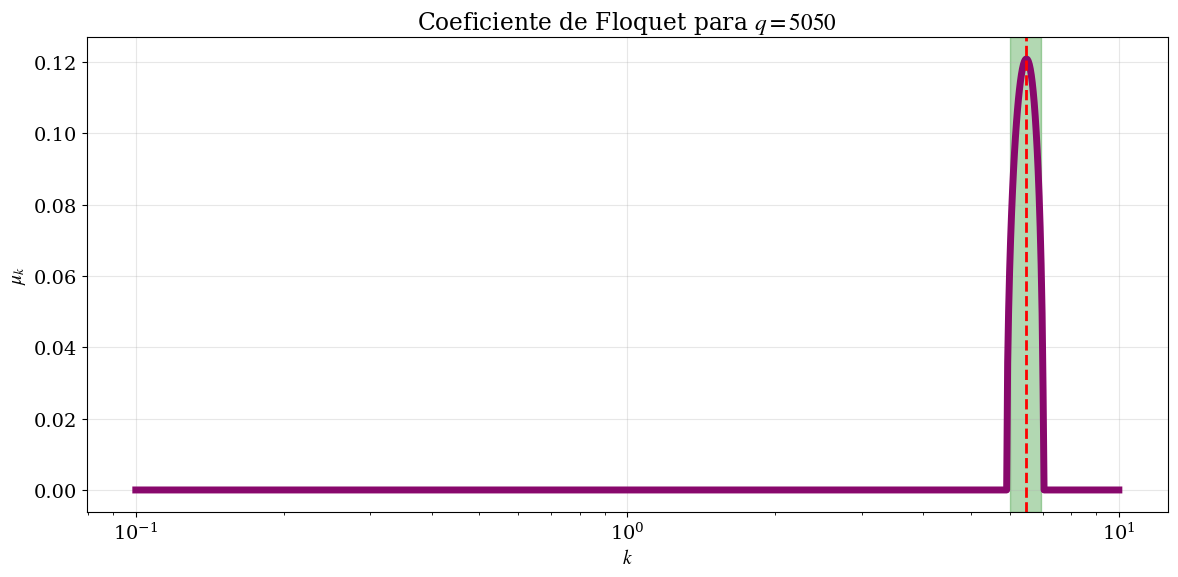

In [7]:
plt.figure(figsize=(12, 6))

plt.title(r'Coeficiente de Floquet para $q=5050$')
plt.plot(ks, np.real(muq), lw = 5, color = "#88086c")
plt.xlabel(r'$k$')
plt.ylabel(r'$\mu_k$')
plt.xscale('log')
plt.grid(alpha = 0.3)
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)
plt.axvline(x=k_maxq, color='red', linestyle='--', lw=2)

plt.tight_layout()
plt.show()

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

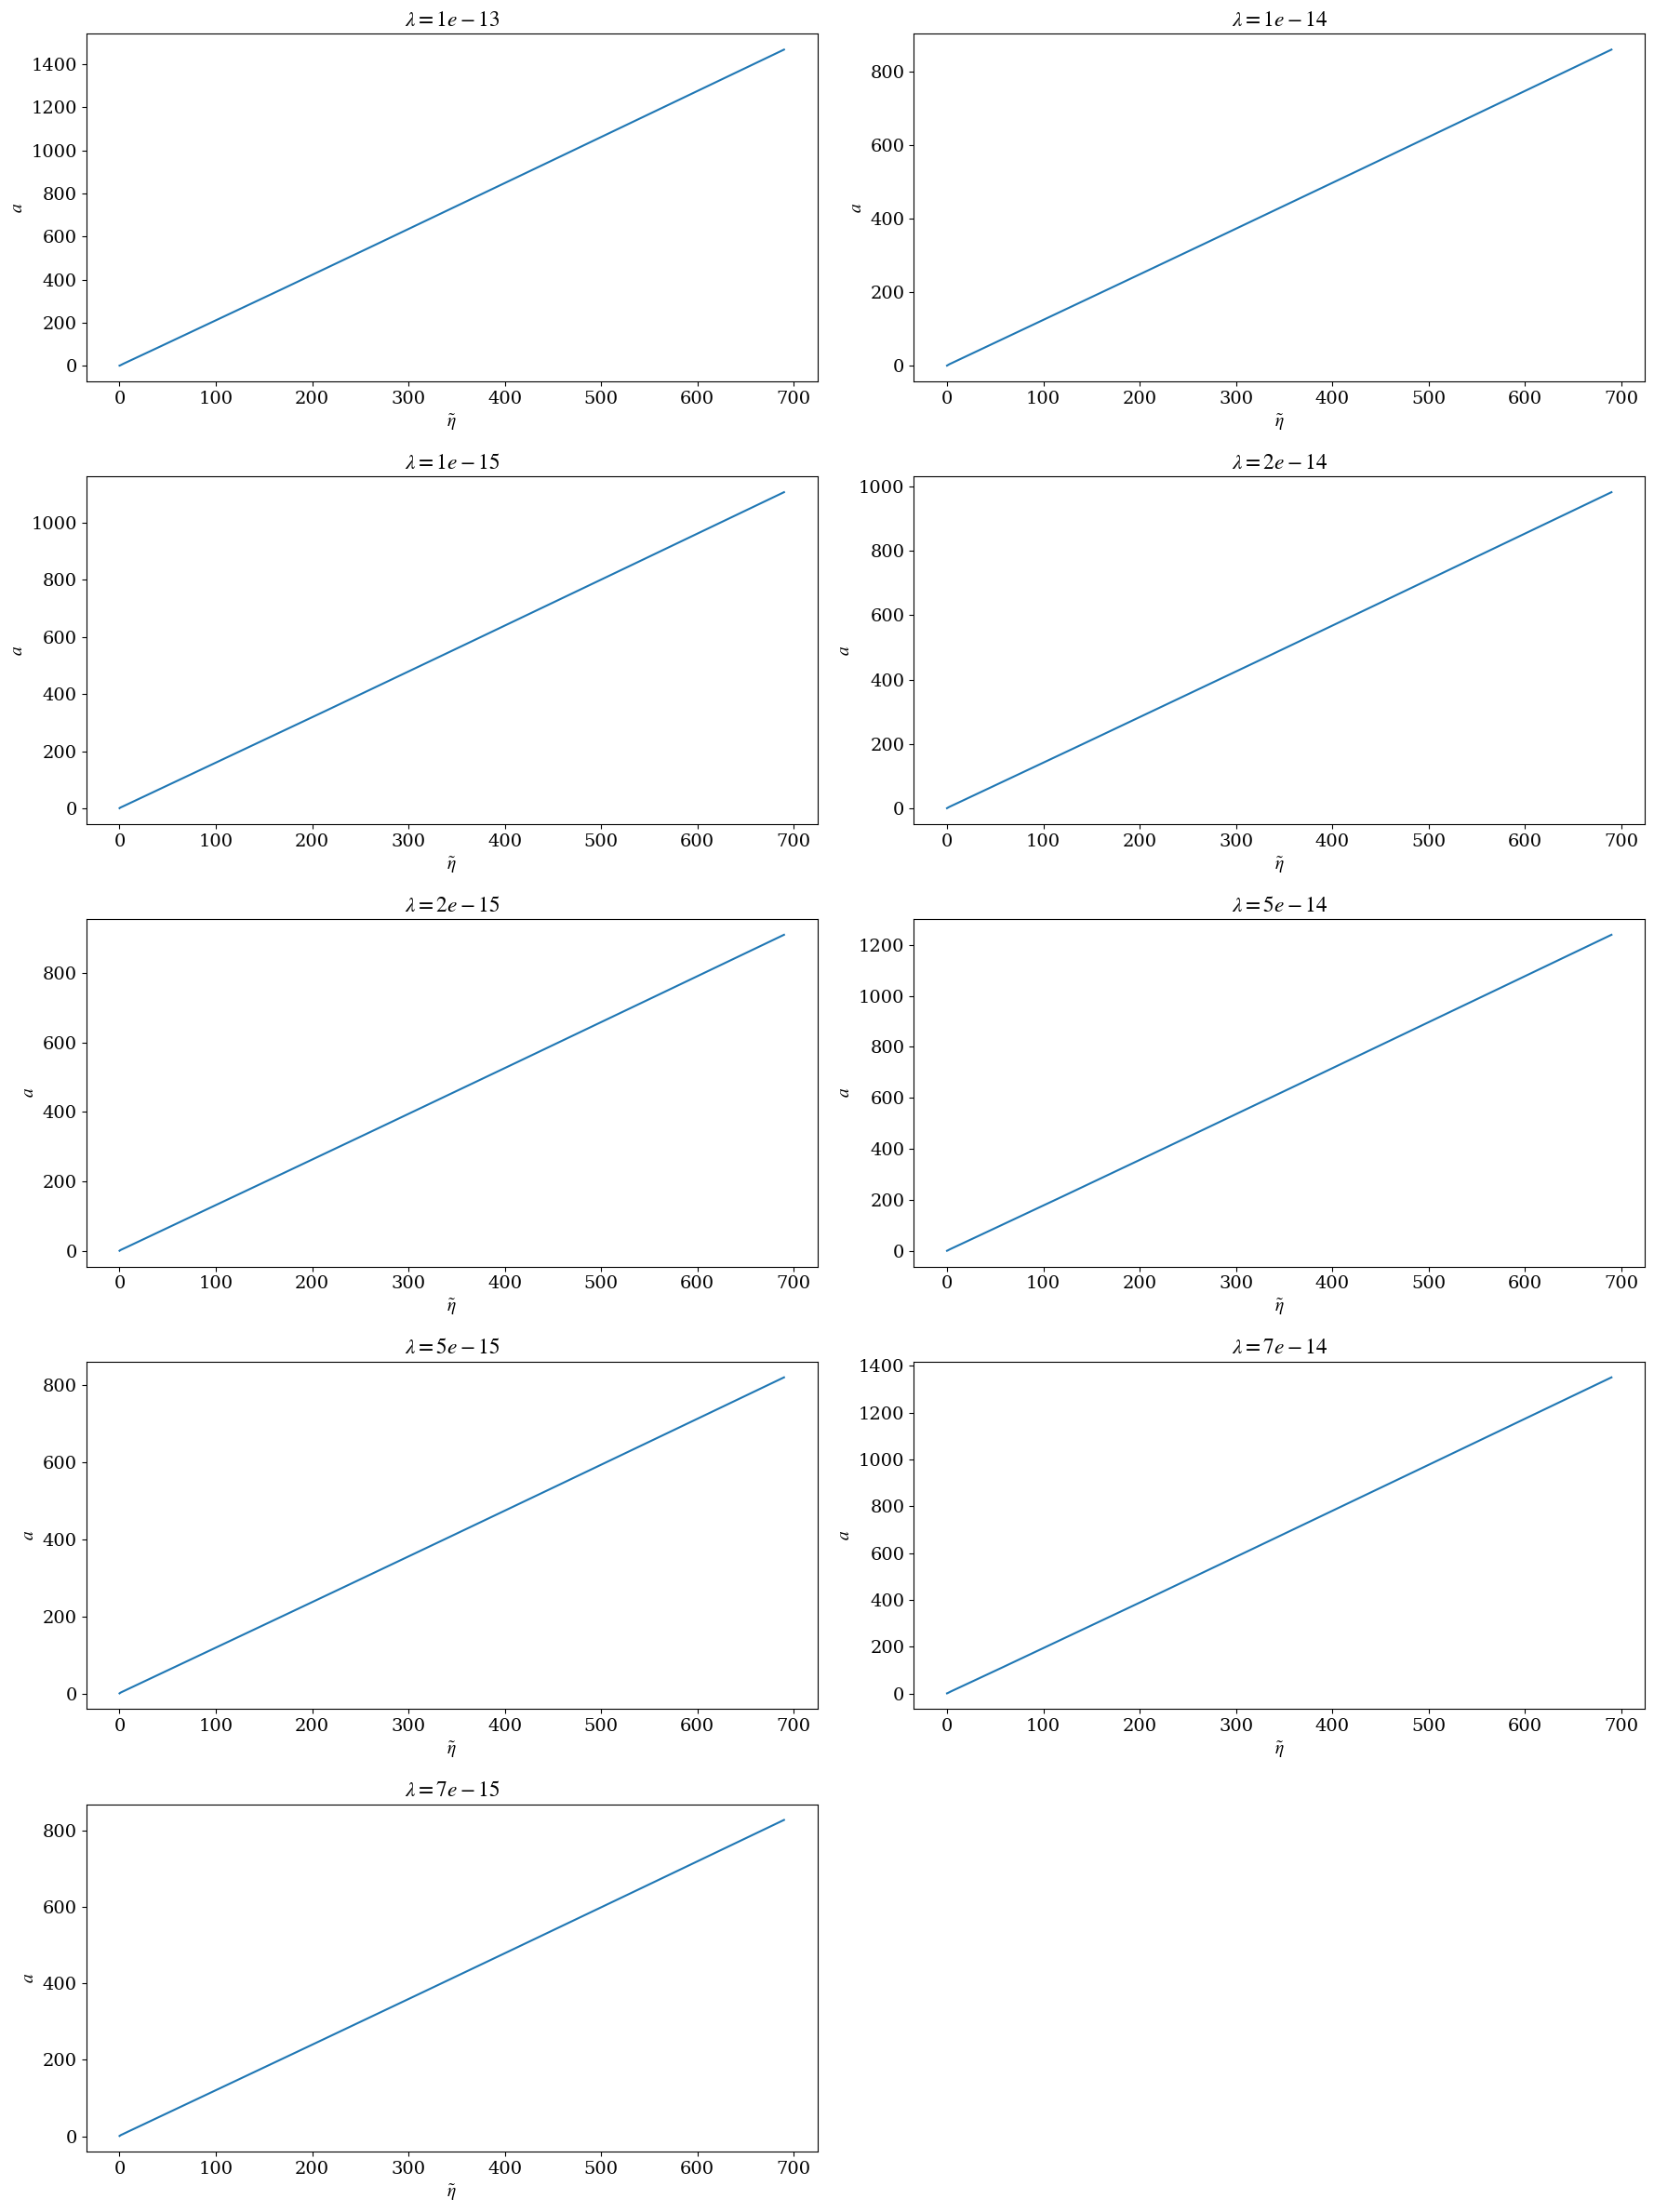

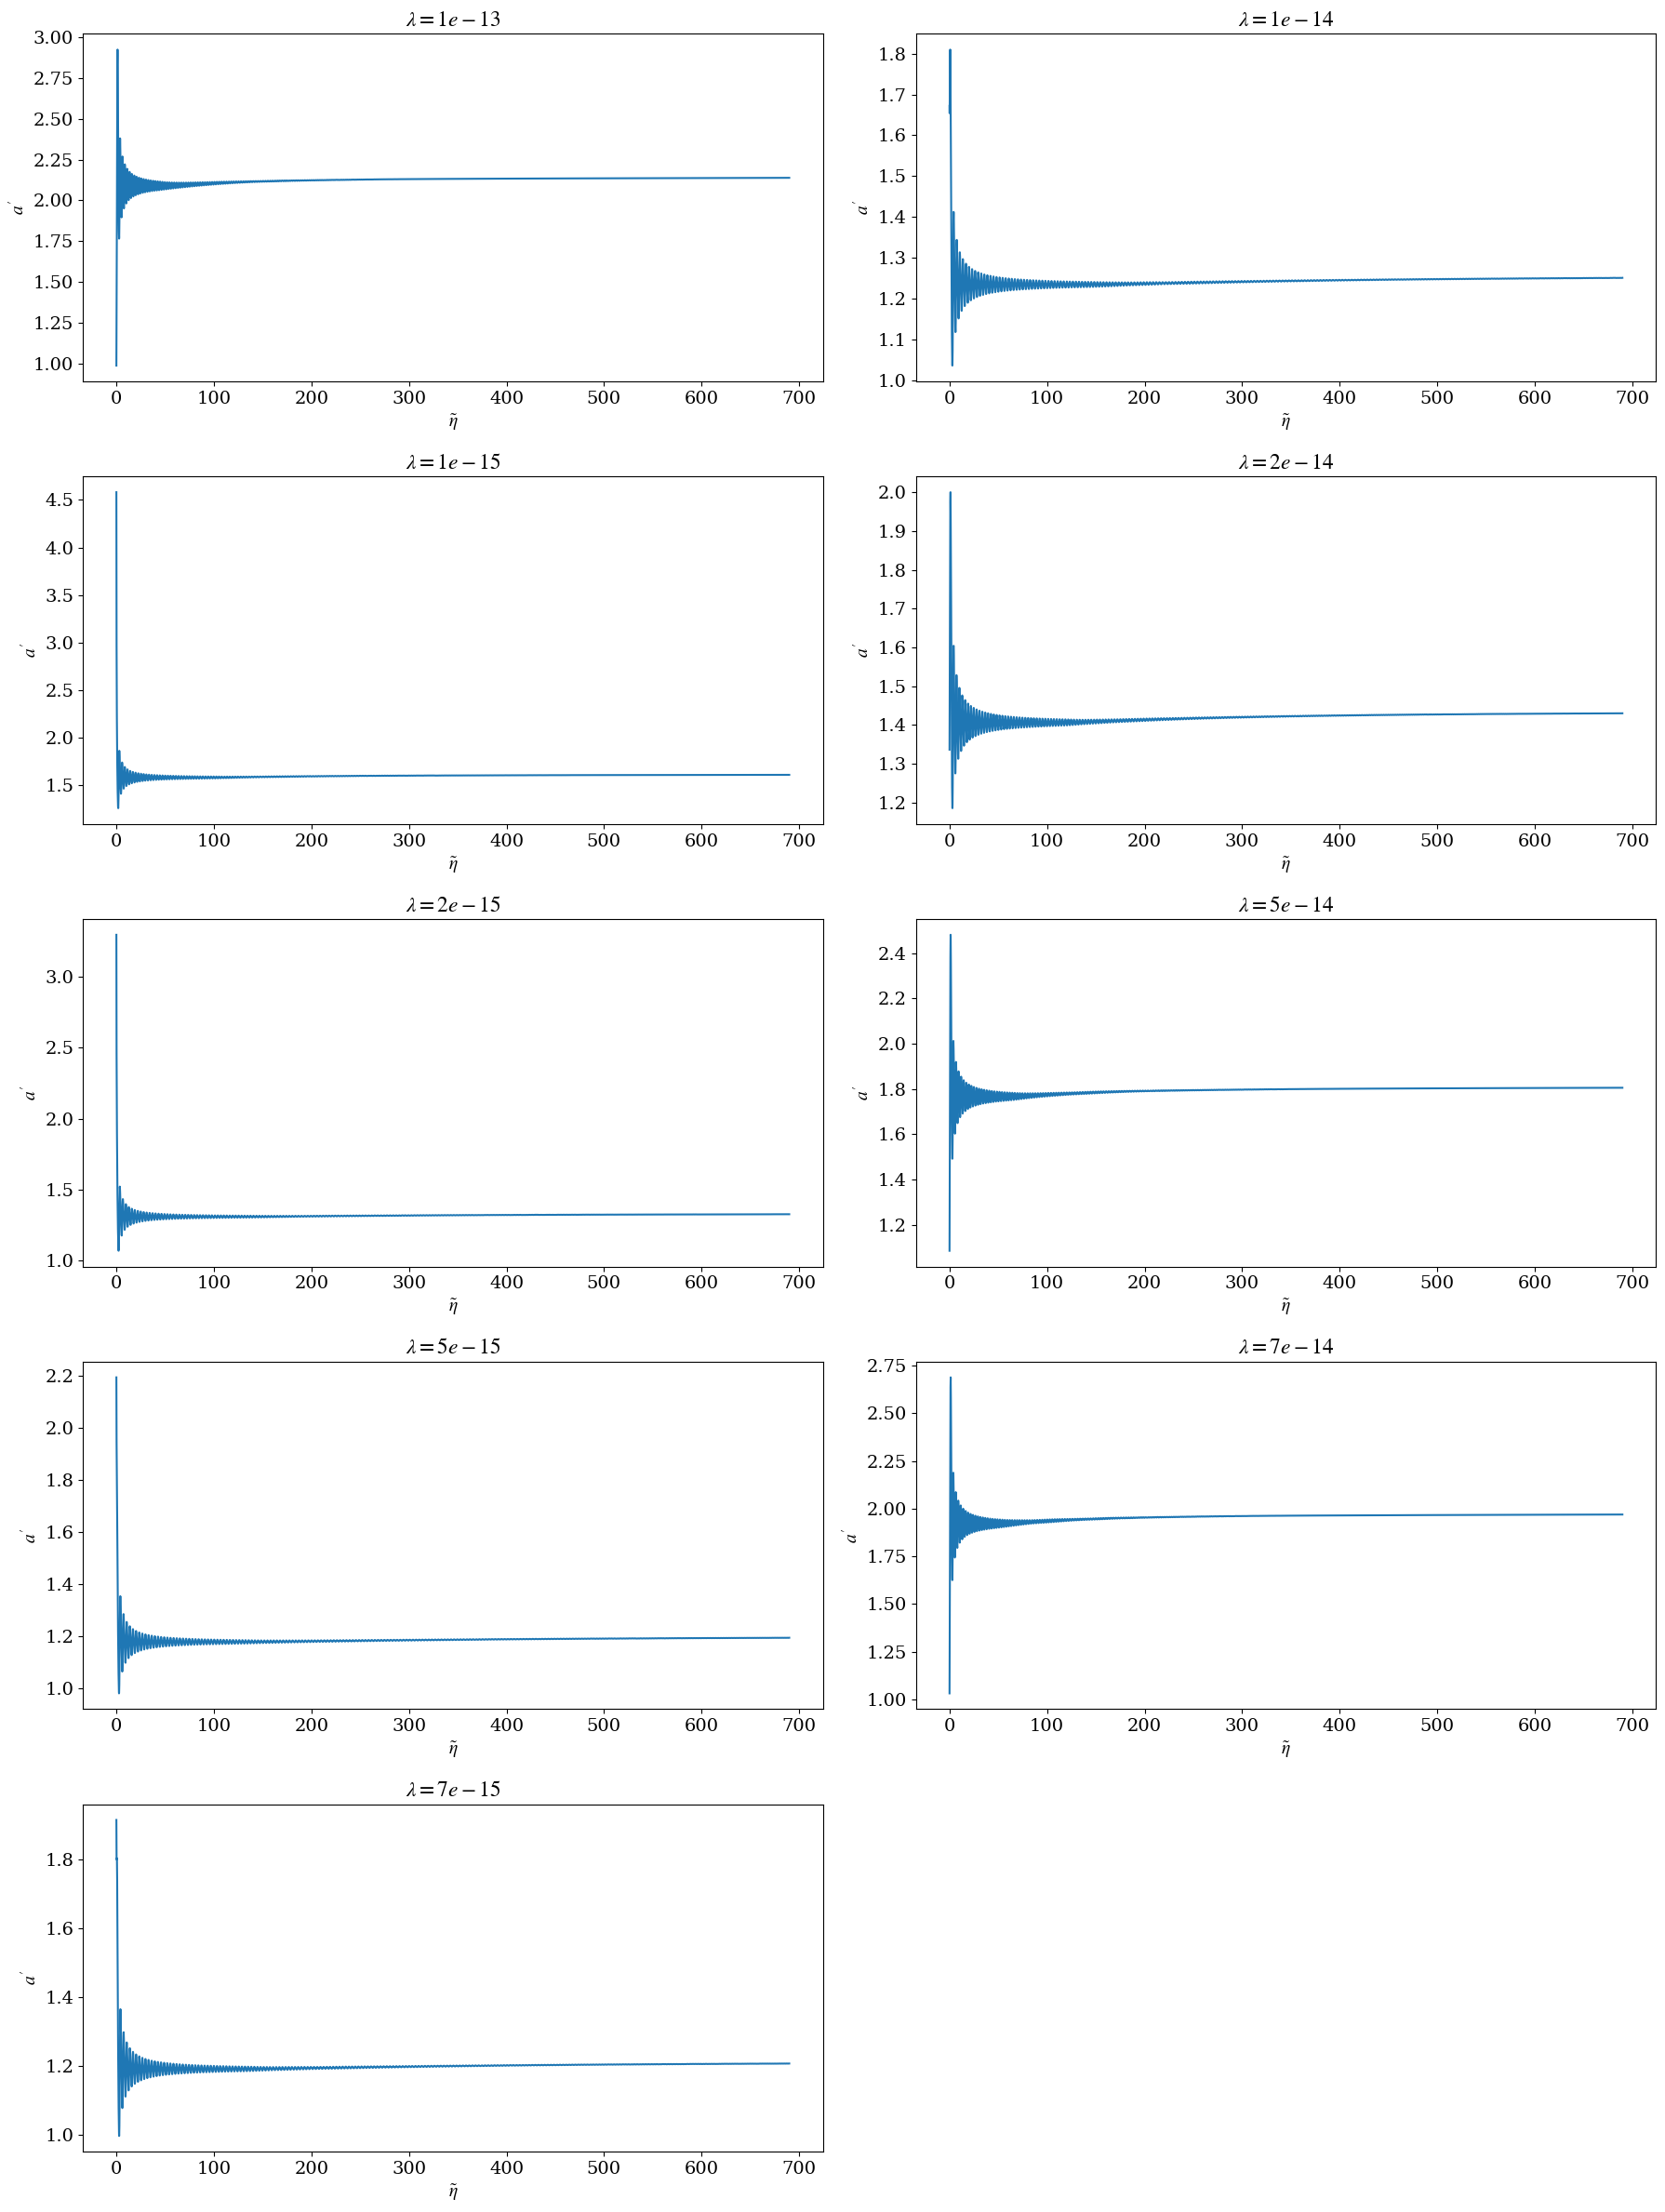

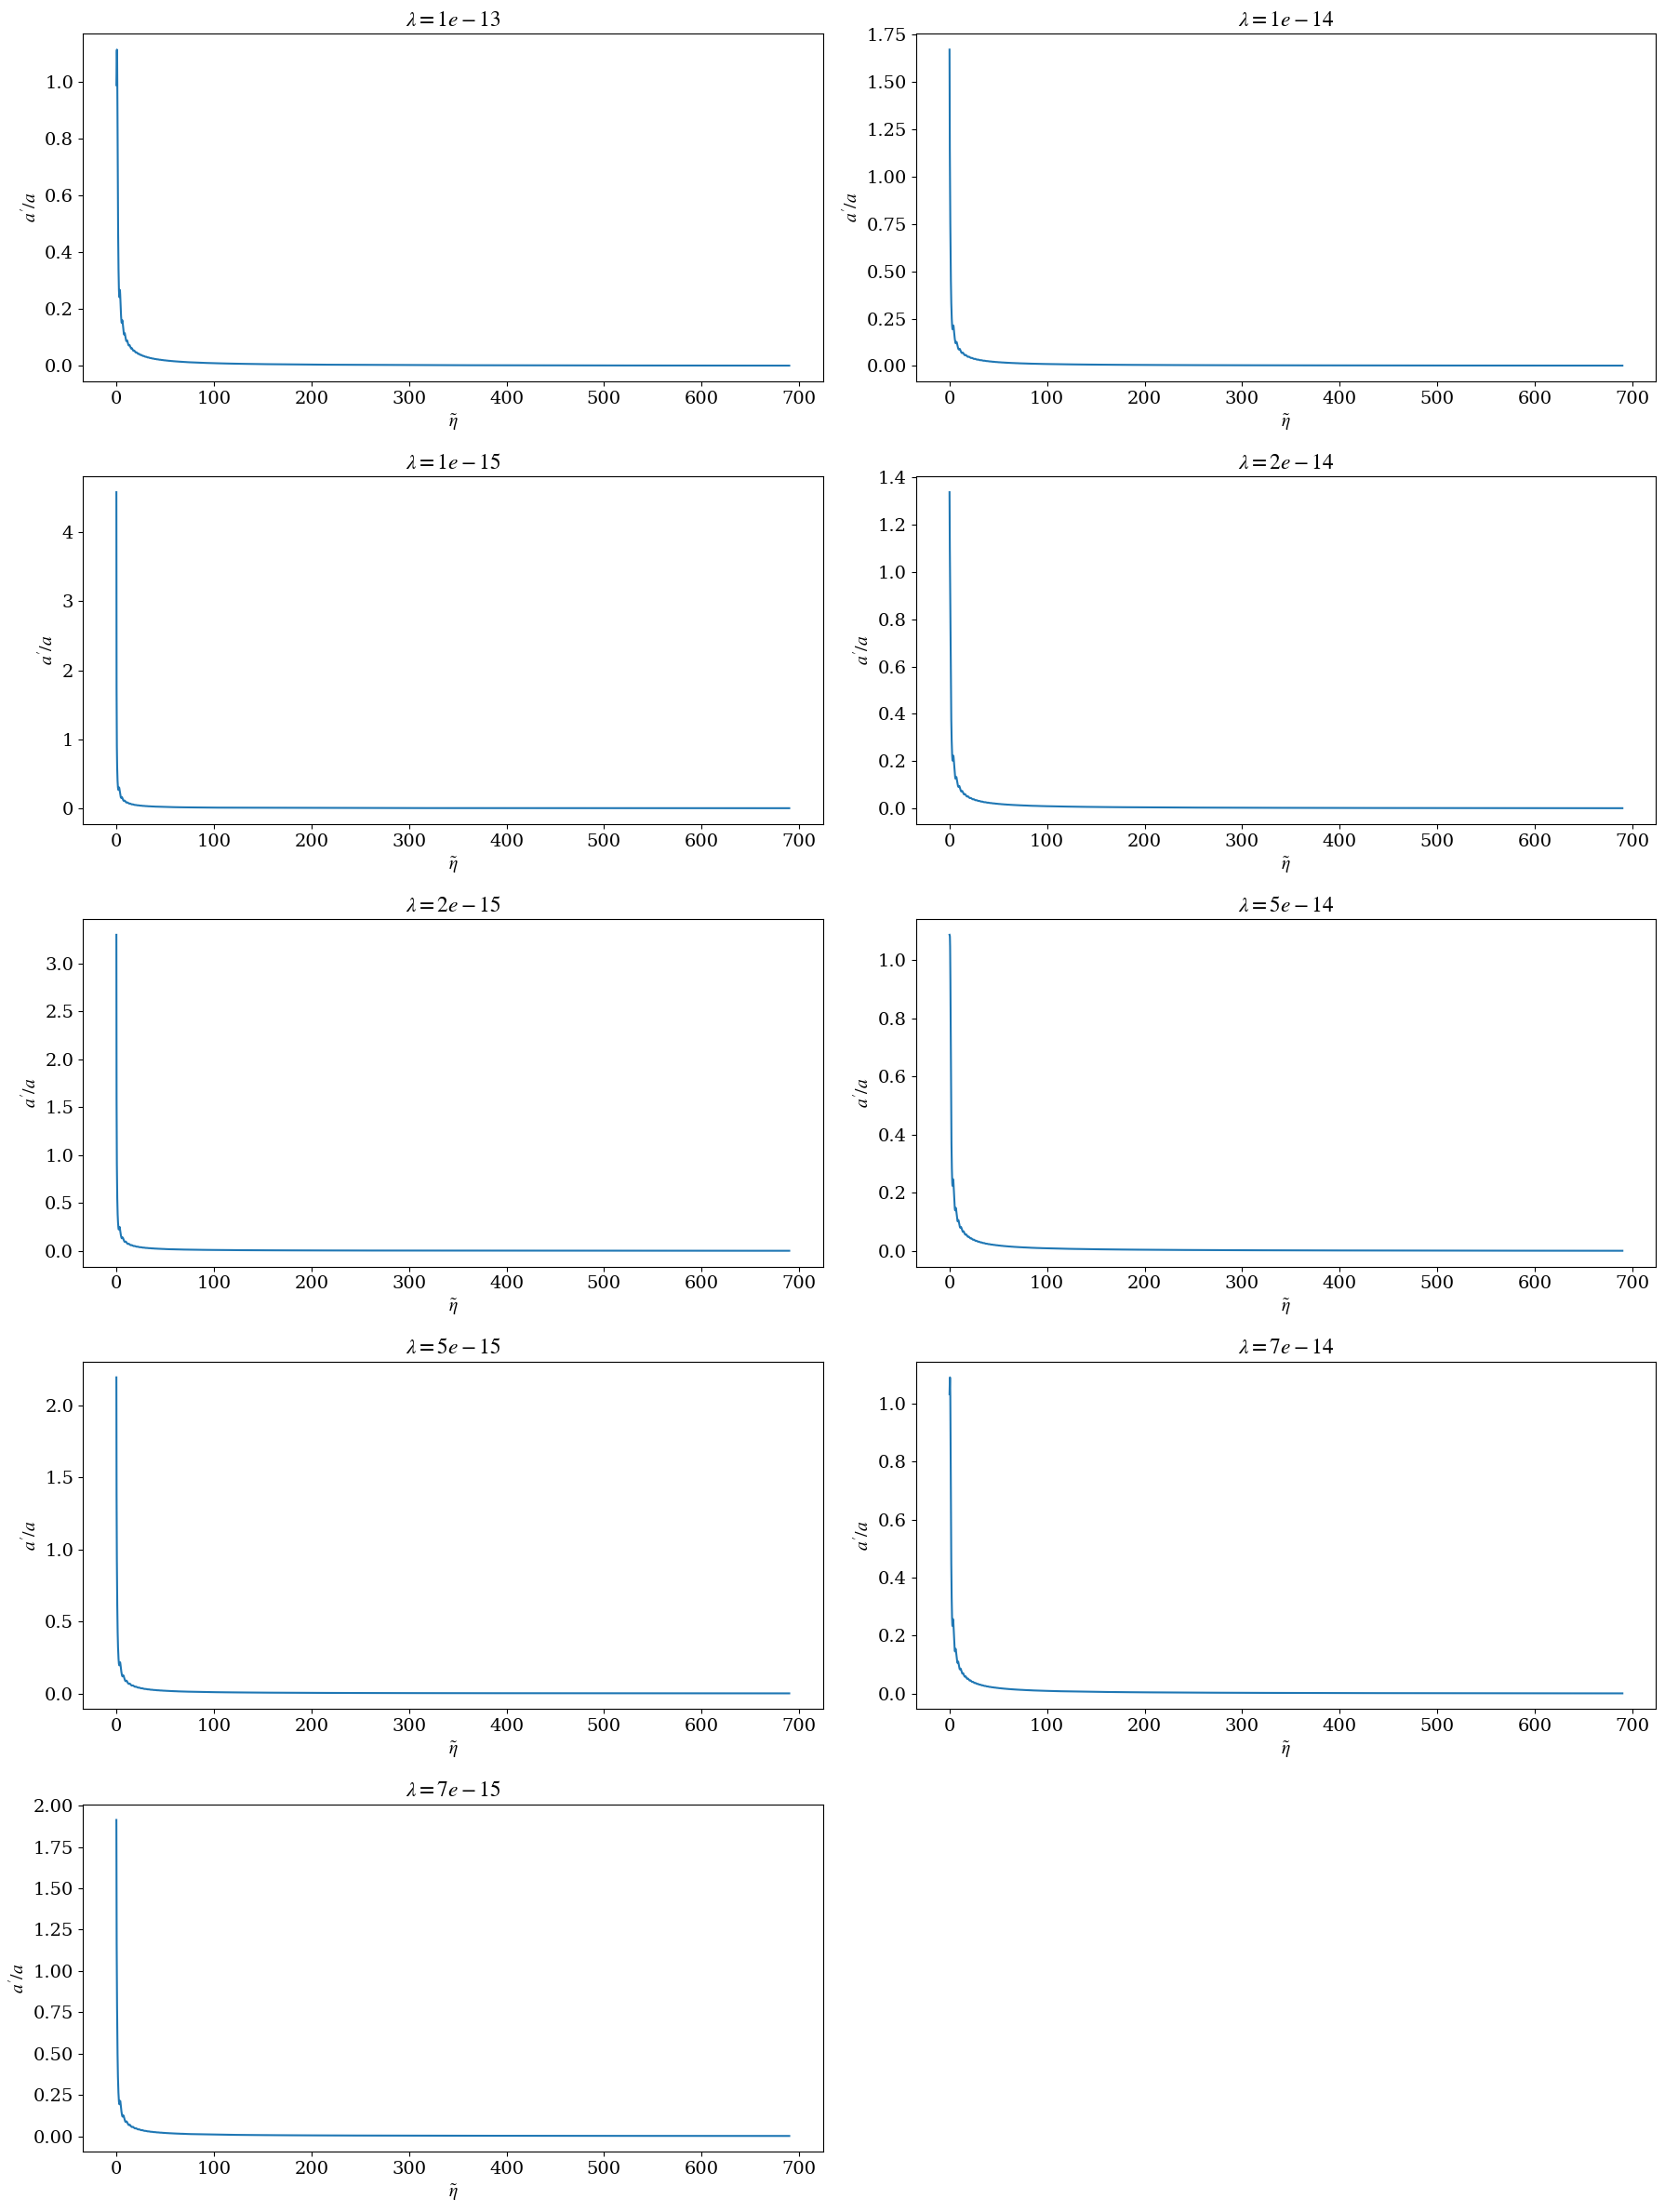

In [8]:
expansion = True

if expansion == True:
    # load the file in aDat
    aDatl1e13 = np.loadtxt(dirl1e13 + "average_scale_factor.txt")
    aDatl1e14 = np.loadtxt(dirl1e14 + "average_scale_factor.txt")
    aDatl1e15 = np.loadtxt(dirl1e15 + "average_scale_factor.txt")
    aDatl2e14 = np.loadtxt(dirl2e14 + "average_scale_factor.txt")
    aDatl2e15 = np.loadtxt(dirl2e15 + "average_scale_factor.txt")
    aDatl5e14 = np.loadtxt(dirl5e14 + "average_scale_factor.txt")
    aDatl5e15 = np.loadtxt(dirl5e15 + "average_scale_factor.txt")
    aDatl7e14 = np.loadtxt(dirl7e14 + "average_scale_factor.txt")
    aDatl7e15 = np.loadtxt(dirl7e15 + "average_scale_factor.txt")
    
    #plot a
    plt.figure(figsize=(18, 24))
    
    plt.subplot(5, 2, 1)
    plt.plot(aDatl1e13[:,0], aDatl1e13[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=1e-13$')

    plt.subplot(5, 2, 2)
    plt.plot(aDatl1e14[:,0], aDatl1e14[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=1e-14$')

    plt.subplot(5, 2, 3)
    plt.plot(aDatl1e15[:,0], aDatl1e15[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=1e-15$')

    plt.subplot(5, 2, 4)
    plt.plot(aDatl2e14[:,0], aDatl2e14[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=2e-14$')

    plt.subplot(5, 2, 5)
    plt.plot(aDatl2e15[:,0], aDatl2e15[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=2e-15$')

    plt.subplot(5, 2, 6)
    plt.plot(aDatl5e14[:,0], aDatl5e14[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=5e-14$')

    plt.subplot(5, 2, 7)
    plt.plot(aDatl5e15[:,0], aDatl5e15[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=5e-15$')

    plt.subplot(5, 2, 8)
    plt.plot(aDatl7e14[:,0], aDatl7e14[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=7e-14$')


    plt.subplot(5, 2, 9)
    plt.plot(aDatl7e15[:,0], aDatl7e15[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\lambda=7e-15$')

    plt.tight_layout()
    plt.show()
    
    #plot a'
    plt.figure(figsize=(18, 24))
    
    plt.subplot(5, 2, 1)
    plt.plot(aDatl1e13[:,0], aDatl1e13[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=1e-13$')

    plt.subplot(5, 2, 2)
    plt.plot(aDatl1e14[:,0], aDatl1e14[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=1e-14$')

    plt.subplot(5, 2, 3)
    plt.plot(aDatl1e15[:,0], aDatl1e15[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=1e-15$')

    plt.subplot(5, 2, 4)
    plt.plot(aDatl2e14[:,0], aDatl2e14[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=2e-14$')

    plt.subplot(5, 2, 5)
    plt.plot(aDatl2e15[:,0], aDatl2e15[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=2e-15$')

    plt.subplot(5, 2, 6)
    plt.plot(aDatl5e14[:,0], aDatl5e14[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=5e-14$')

    plt.subplot(5, 2, 7)
    plt.plot(aDatl5e15[:,0], aDatl5e15[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=5e-15$')

    plt.subplot(5, 2, 8)
    plt.plot(aDatl7e14[:,0], aDatl7e14[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=7e-14$')

    plt.subplot(5, 2, 9)
    plt.plot(aDatl7e15[:,0], aDatl7e15[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=7e-15$')
    
    plt.tight_layout()
    plt.show()
    
    #plot a'/a
    plt.figure(figsize=(18, 24))
    
    plt.subplot(5, 2, 1)
    plt.plot(aDatl1e13[:,0], aDatl1e13[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=1e-13$')

    plt.subplot(5, 2, 2)
    plt.plot(aDatl1e14[:,0], aDatl1e14[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=1e-14$')

    plt.subplot(5, 2, 3)
    plt.plot(aDatl1e15[:,0], aDatl1e15[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=1e-15$')

    plt.subplot(5, 2, 4)
    plt.plot(aDatl2e14[:,0], aDatl2e14[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=2e-14$')

    plt.subplot(5, 2, 5)
    plt.plot(aDatl2e15[:,0], aDatl2e15[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=2e-15$')

    plt.subplot(5, 2, 6)
    plt.plot(aDatl5e14[:,0], aDatl5e14[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=5e-14$')

    plt.subplot(5, 2, 7)
    plt.plot(aDatl5e15[:,0], aDatl5e15[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=5e-15$')

    plt.subplot(5, 2, 8)
    plt.plot(aDatl7e14[:,0], aDatl7e14[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=7e-14$')

    plt.subplot(5, 2, 9)
    plt.plot(aDatl7e15[:,0], aDatl7e15[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\lambda=7e-15$')
    
    plt.tight_layout()
    plt.show()

else:
    aDatl1e13 = None
    aDatl1e14 = None
    aDatl1e15 = None
    aDatl2e14 = None
    aDatl2e15 = None
    aDatl5e14 = None
    aDatl5e15 = None
    aDatl7e14 = None
    aDatl7e15 = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [9]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")
    
    if aDat is not None:
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

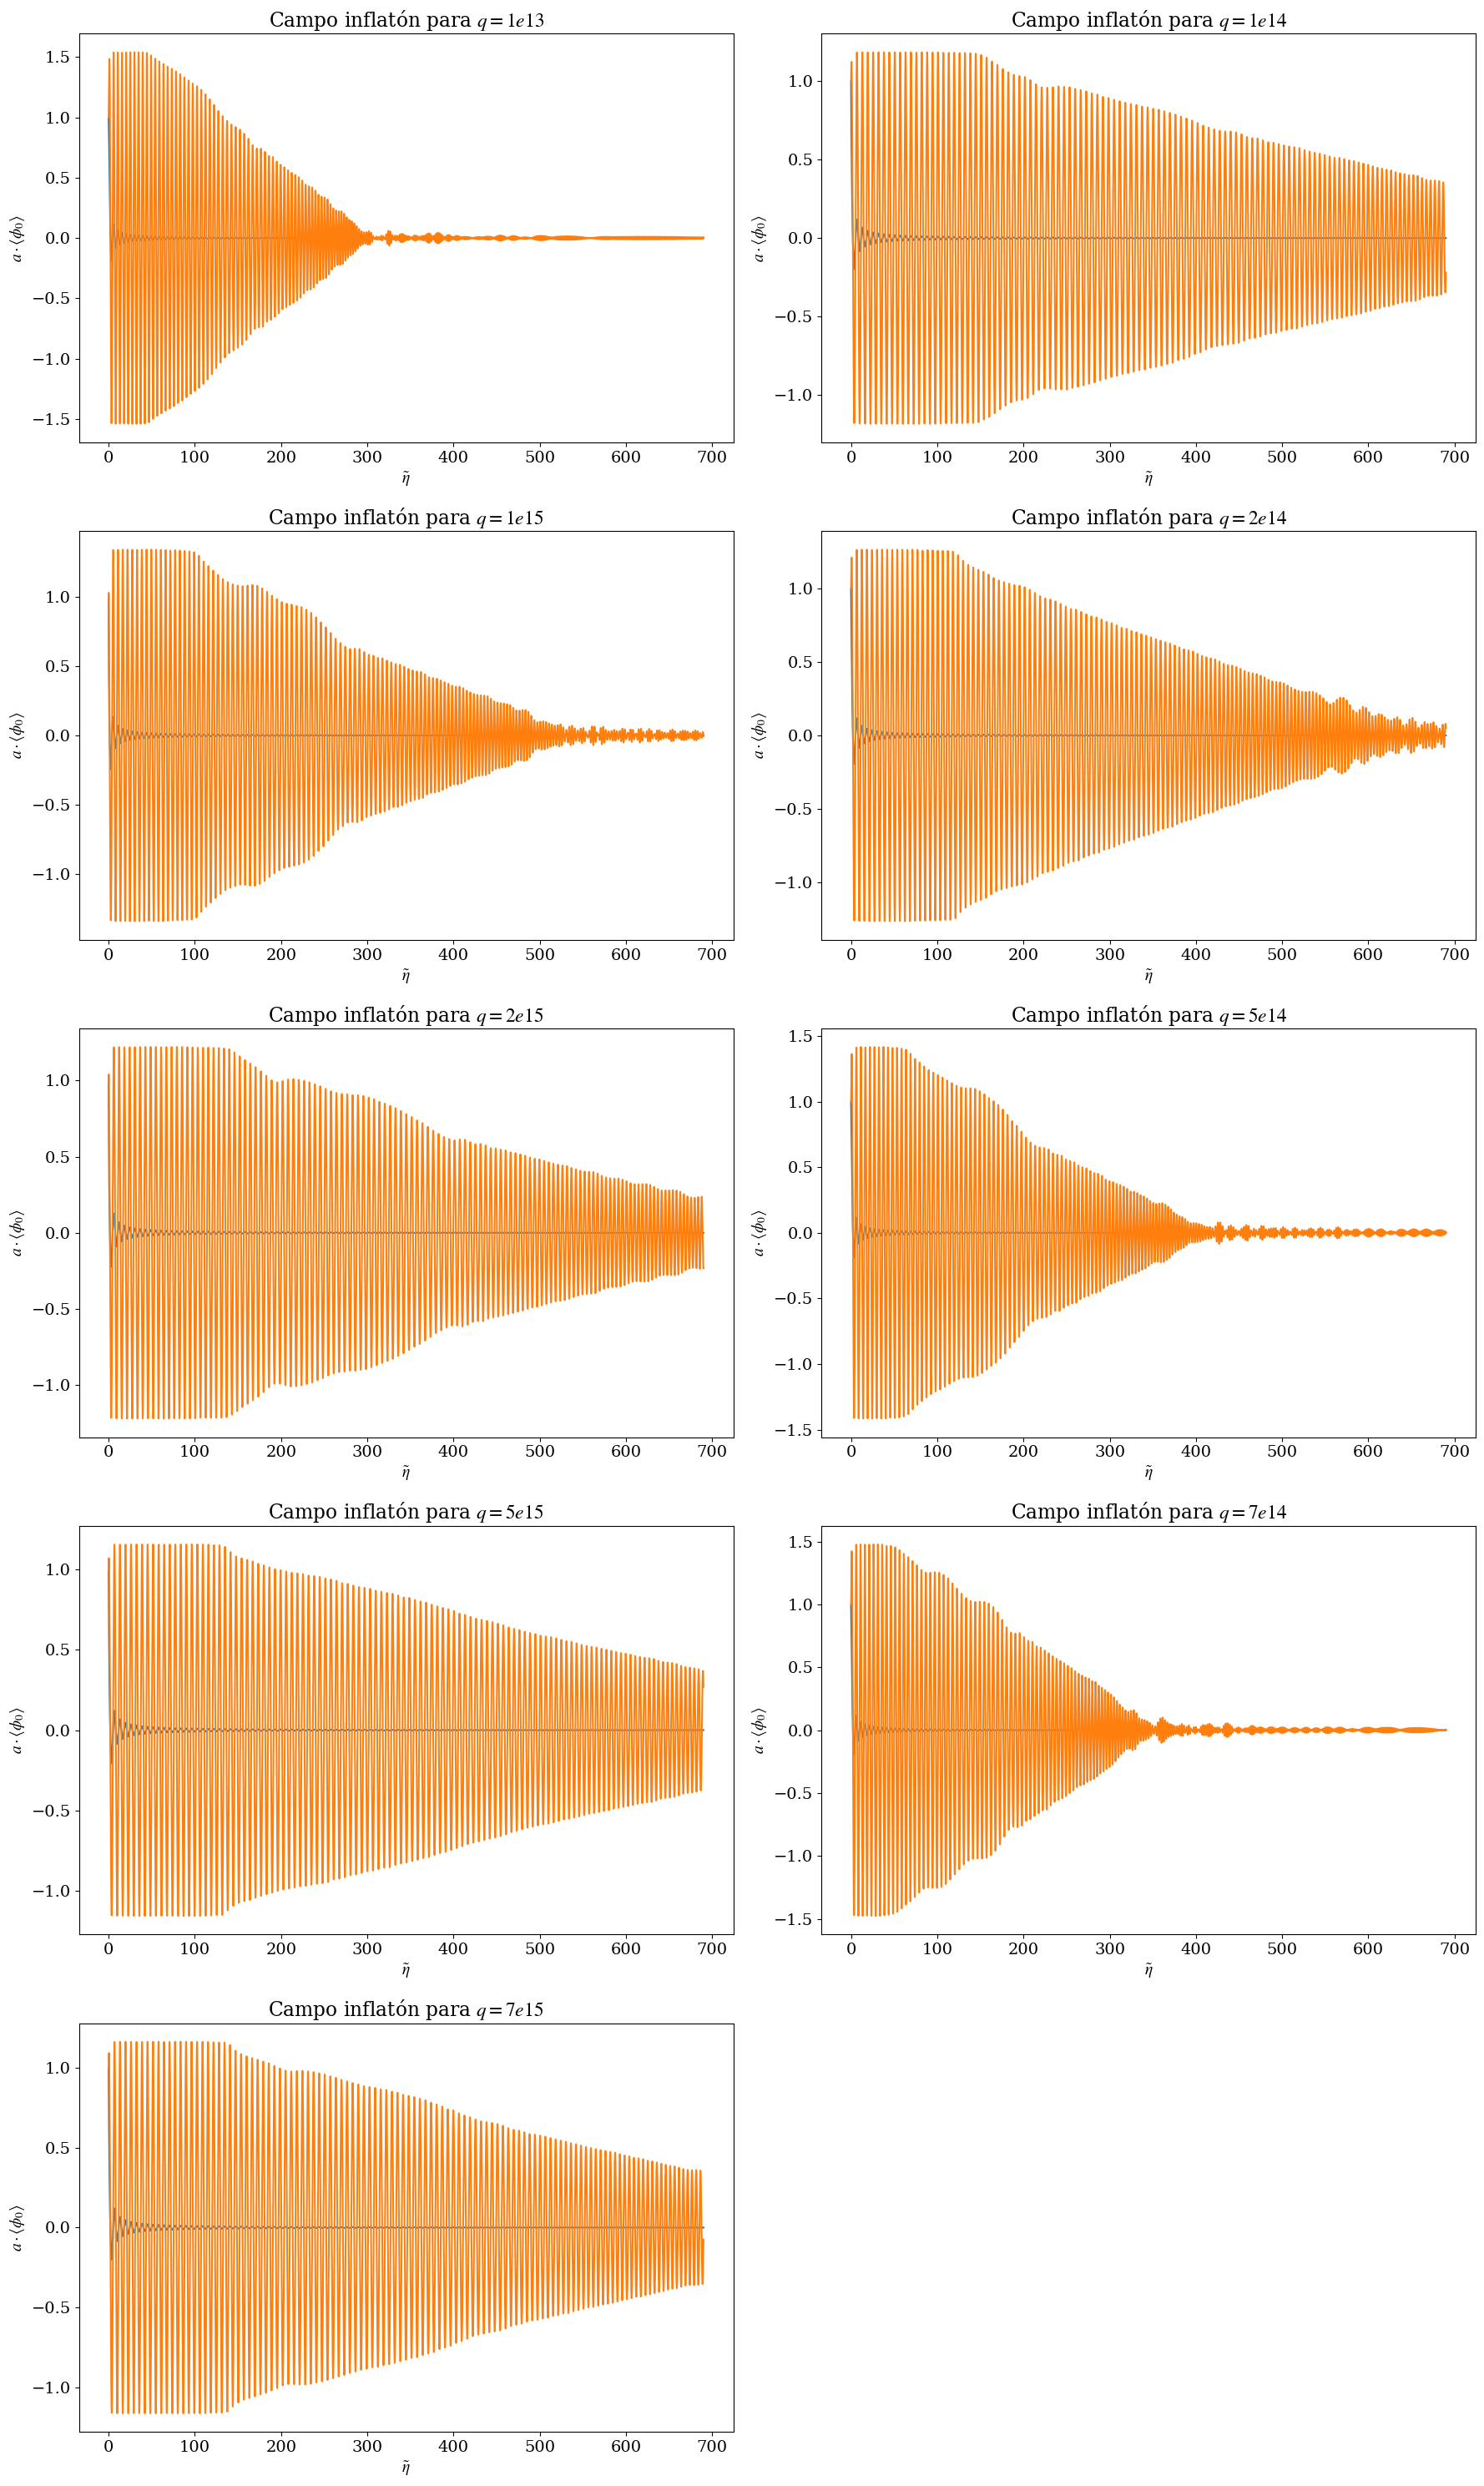

In [10]:
infDatl1e13 = np.loadtxt(dirl1e13 + "average_scalar_0.txt")
infDatl1e14 = np.loadtxt(dirl1e14 + "average_scalar_0.txt")
infDatl1e15 = np.loadtxt(dirl1e15 + "average_scalar_0.txt")
infDatl2e14 = np.loadtxt(dirl2e14 + "average_scalar_0.txt")
infDatl2e15 = np.loadtxt(dirl2e15 + "average_scalar_0.txt")
infDatl5e14 = np.loadtxt(dirl5e14 + "average_scalar_0.txt")
infDatl5e15 = np.loadtxt(dirl5e15 + "average_scalar_0.txt")
infDatl7e14 = np.loadtxt(dirl7e14 + "average_scalar_0.txt")
infDatl7e15 = np.loadtxt(dirl7e15 + "average_scalar_0.txt")

plt.figure(figsize=(18, 30))

plt.subplot(5, 2, 1)
plot_fld(infDatl1e13,"0",aDatl1e13)
plt.title(r'Campo inflatón para $q=1e13$')

plt.subplot(5, 2, 2)
plot_fld(infDatl1e14,"0",aDatl1e14)
plt.title(r'Campo inflatón para $q=1e14$')

plt.subplot(5, 2, 3)
plot_fld(infDatl1e15,"0",aDatl1e15)
plt.title(r'Campo inflatón para $q=1e15$')

plt.subplot(5, 2, 4)
plot_fld(infDatl2e14,"0",aDatl2e14)
plt.title(r'Campo inflatón para $q=2e14$')

plt.subplot(5, 2, 5)
plot_fld(infDatl2e15,"0",aDatl2e15)
plt.title(r'Campo inflatón para $q=2e15$')

plt.subplot(5, 2, 6)
plot_fld(infDatl5e14,"0",aDatl5e14)
plt.title(r'Campo inflatón para $q=5e14$')

plt.subplot(5, 2, 7)
plot_fld(infDatl5e15,"0",aDatl5e15)
plt.title(r'Campo inflatón para $q=5e15$')

plt.subplot(5, 2, 8)
plot_fld(infDatl7e14,"0",aDatl7e14)
plt.title(r'Campo inflatón para $q=7e14$')

plt.subplot(5, 2, 9)
plot_fld(infDatl7e15,"0",aDatl7e15)
plt.title(r'Campo inflatón para $q=7e15$')

plt.tight_layout()
plt.show()

## Field $1$ (daughter field)

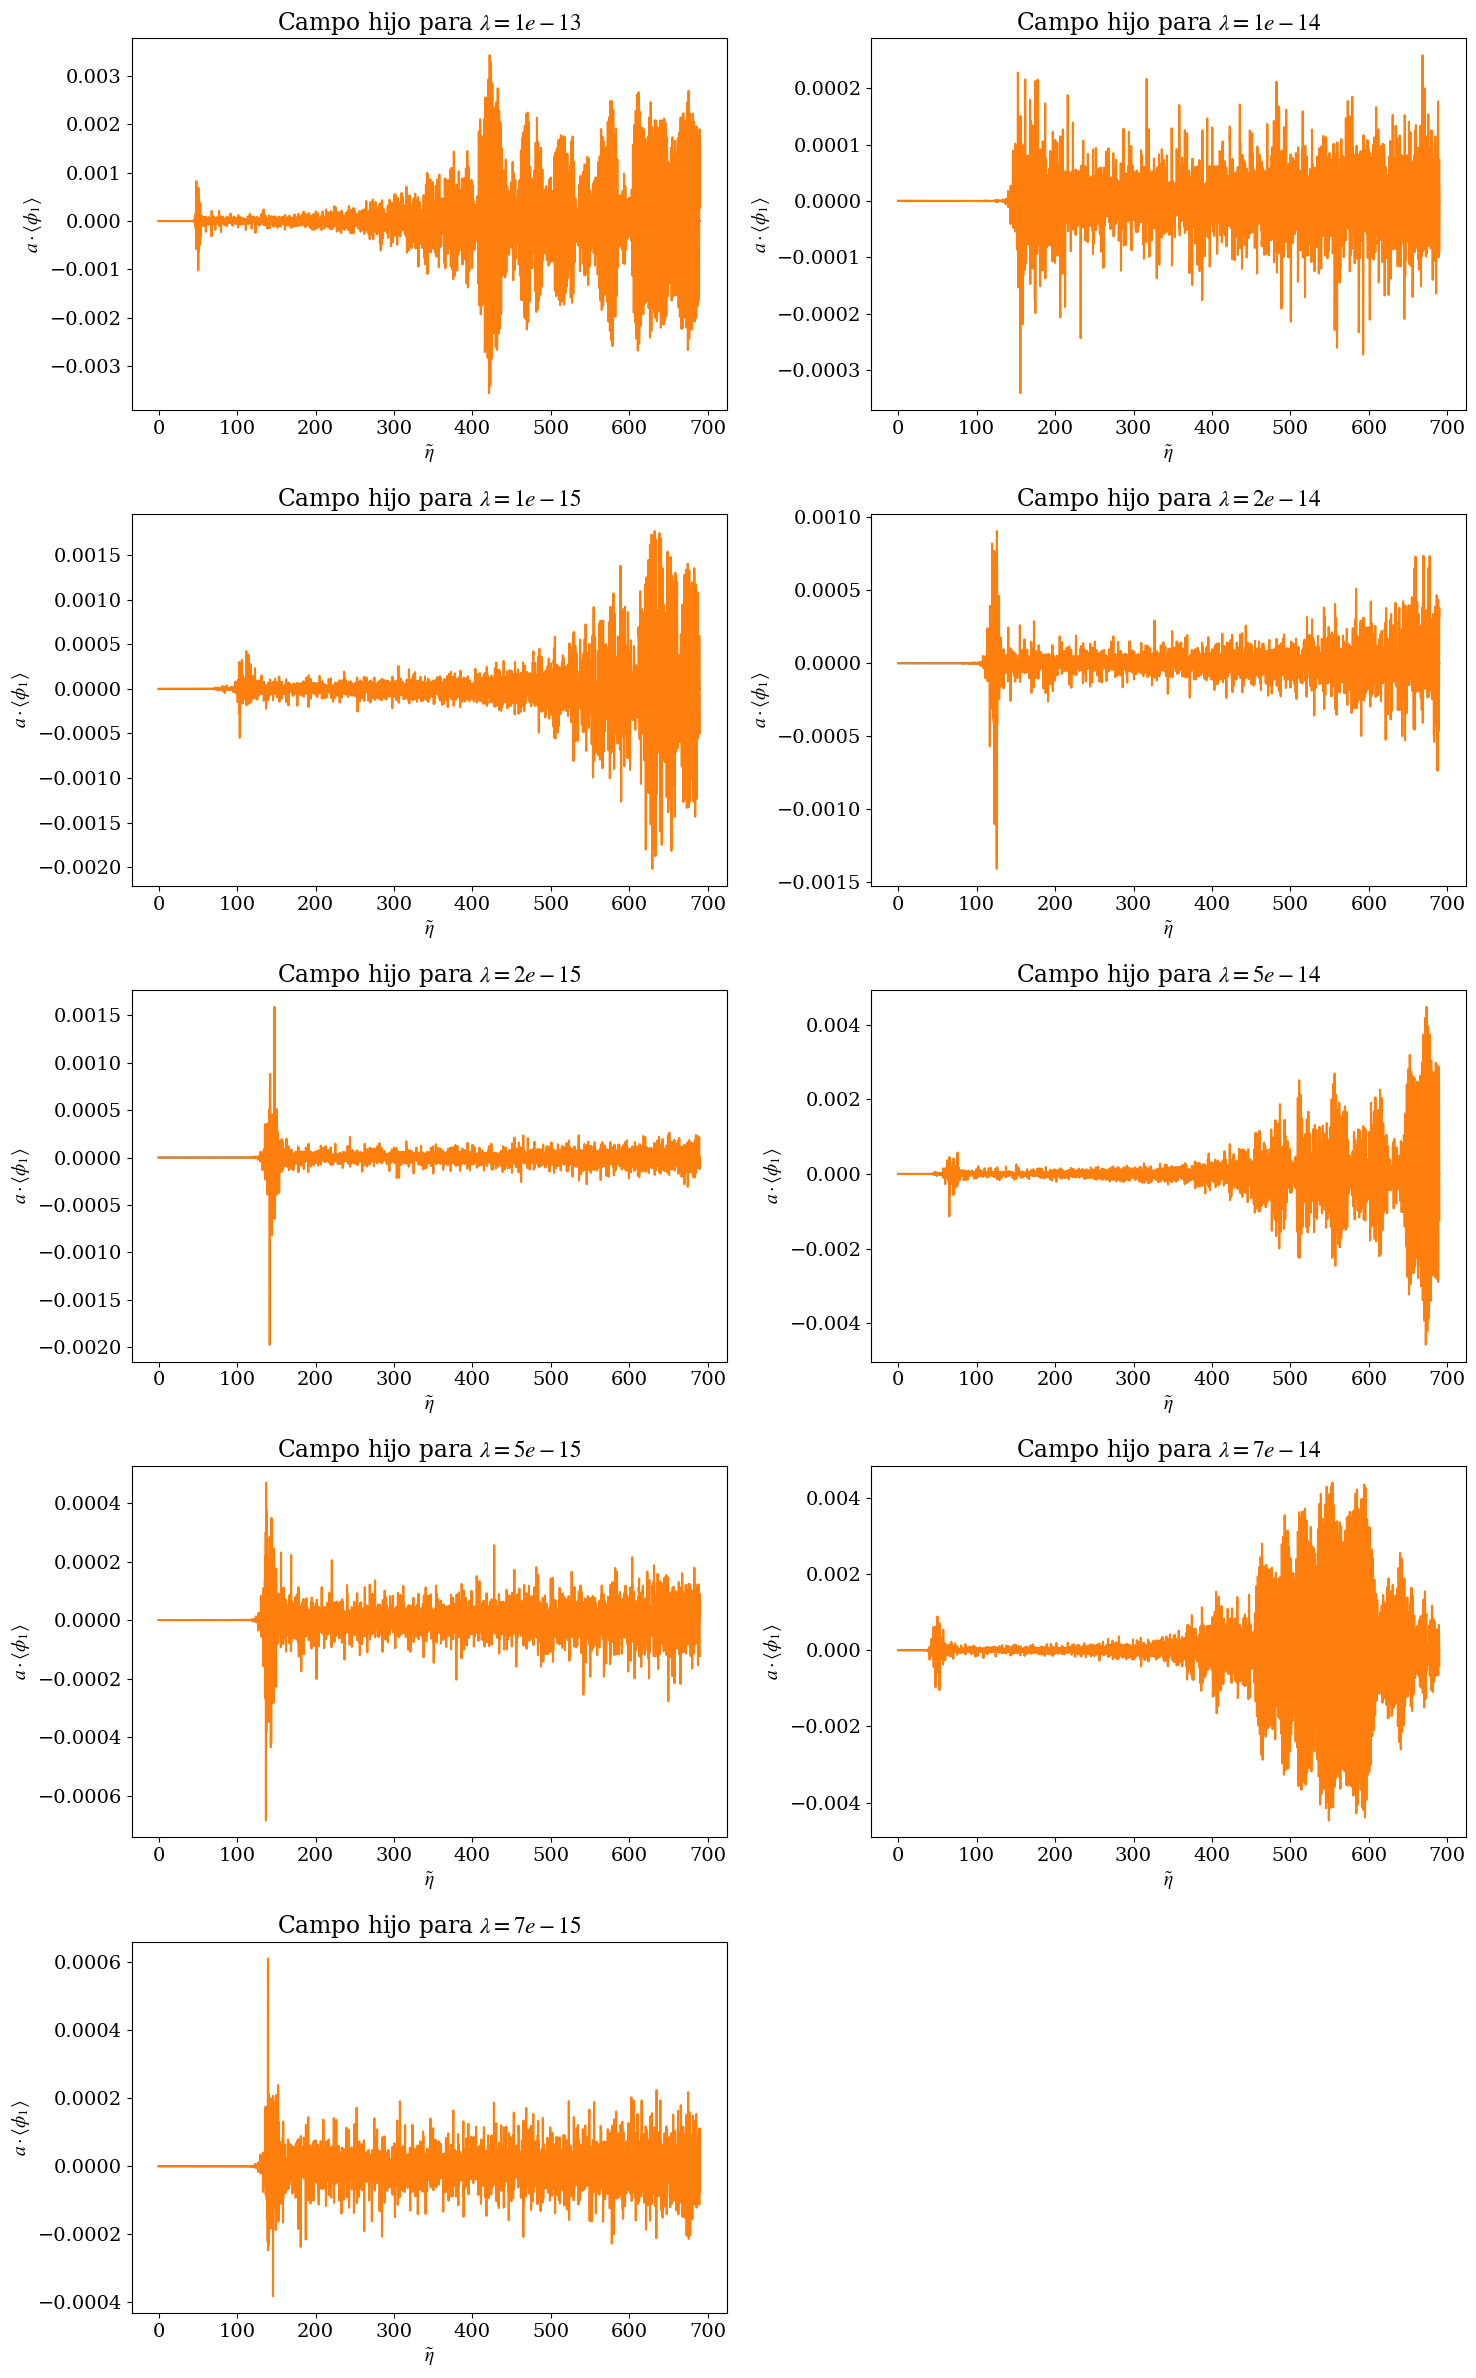

In [11]:
infDatl1e13 = np.loadtxt(dirl1e13 + "average_scalar_1.txt")
infDatl1e14 = np.loadtxt(dirl1e14 + "average_scalar_1.txt")
infDatl1e15 = np.loadtxt(dirl1e15 + "average_scalar_1.txt")
infDatl2e14 = np.loadtxt(dirl2e14 + "average_scalar_1.txt")
infDatl2e15 = np.loadtxt(dirl2e15 + "average_scalar_1.txt")
infDatl5e14 = np.loadtxt(dirl5e14 + "average_scalar_1.txt")
infDatl5e15 = np.loadtxt(dirl5e15 + "average_scalar_1.txt")
infDatl7e14 = np.loadtxt(dirl7e14 + "average_scalar_1.txt")
infDatl7e15 = np.loadtxt(dirl7e15 + "average_scalar_1.txt")

plt.figure(figsize=(15, 24))

plt.subplot(5, 2, 1)
plot_fld(infDatl1e13,"1",aDatl1e13)
plt.title(r'Campo hijo para $\lambda=1e-13$')

plt.subplot(5, 2, 2)
plot_fld(infDatl1e14,"1",aDatl1e14)
plt.title(r'Campo hijo para $\lambda=1e-14$')

plt.subplot(5, 2, 3)
plot_fld(infDatl1e15,"1",aDatl1e15)
plt.title(r'Campo hijo para $\lambda=1e-15$')

plt.subplot(5, 2, 4)
plot_fld(infDatl2e14,"1",aDatl2e14)
plt.title(r'Campo hijo para $\lambda=2e-14$')

plt.subplot(5, 2, 5)
plot_fld(infDatl2e15,"1",aDatl2e15)
plt.title(r'Campo hijo para $\lambda=2e-15$')

plt.subplot(5, 2, 6)
plot_fld(infDatl5e14,"1",aDatl5e14)
plt.title(r'Campo hijo para $\lambda=5e-14$')

plt.subplot(5, 2, 7)
plot_fld(infDatl5e15,"1",aDatl5e15)
plt.title(r'Campo hijo para $\lambda=5e-15$')

plt.subplot(5, 2, 8)
plot_fld(infDatl7e14,"1",aDatl7e14)
plt.title(r'Campo hijo para $\lambda=7e-14$')

plt.subplot(5, 2, 9)
plot_fld(infDatl7e15,"1",aDatl7e15)
plt.title(r'Campo hijo para $\lambda=7e-15$')

plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

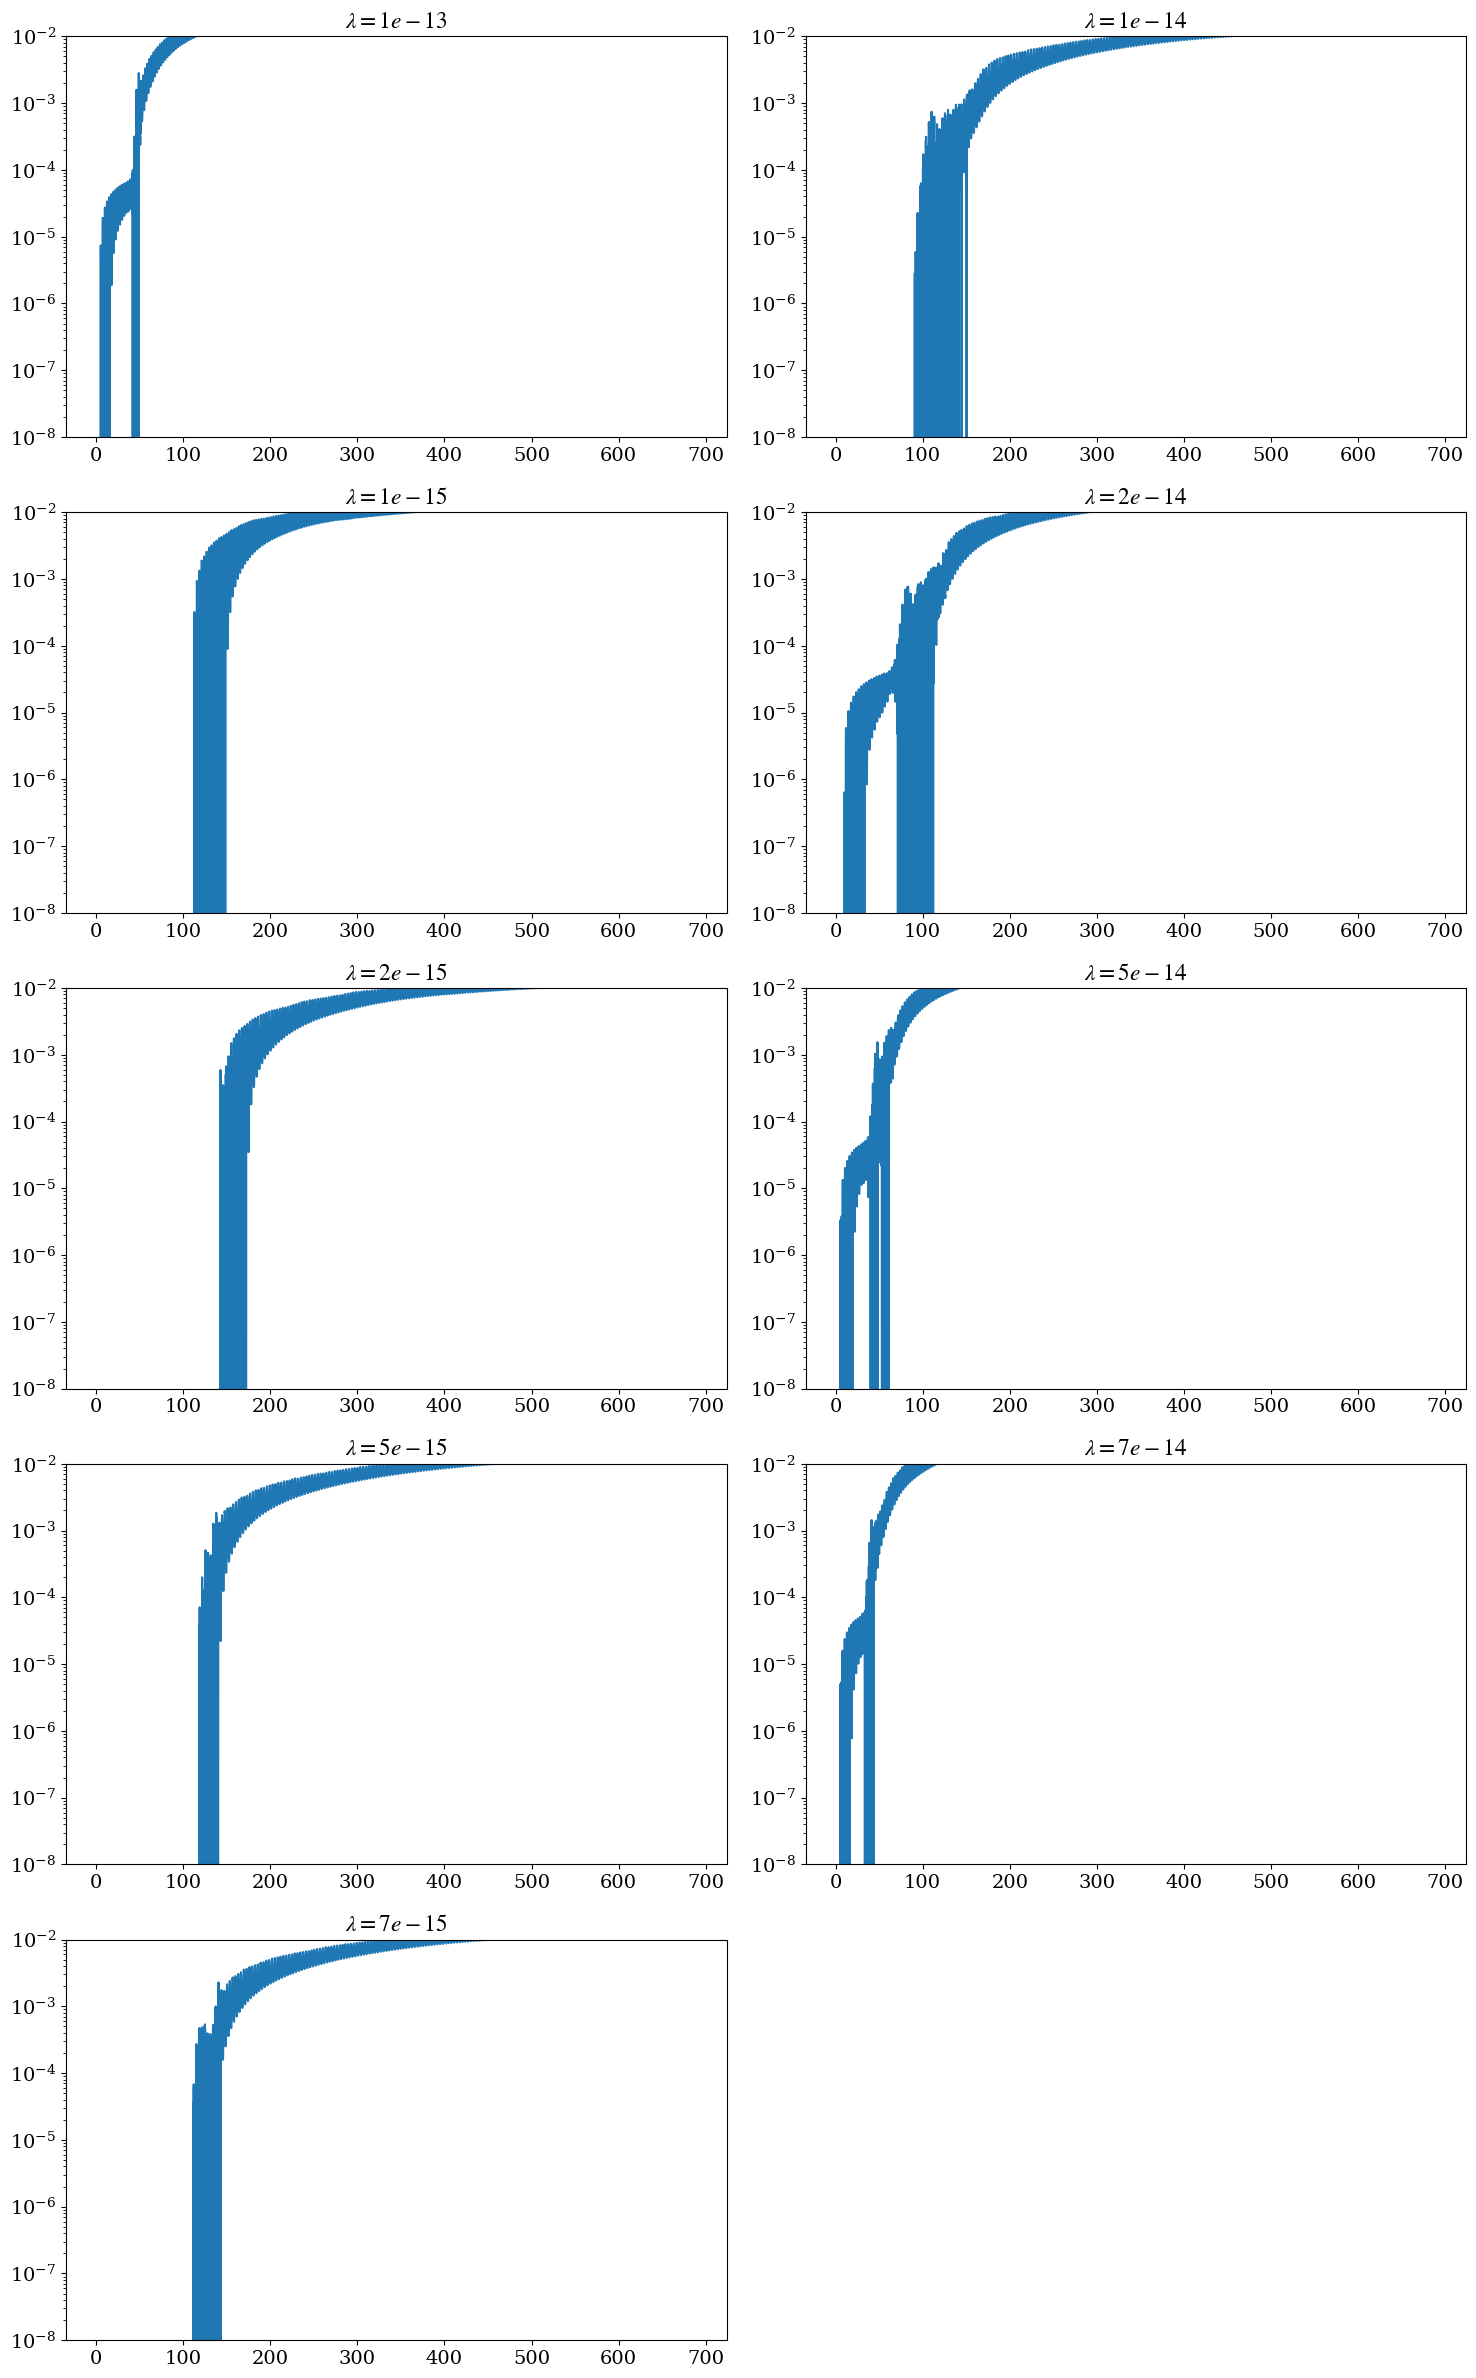

In [12]:
enConsDatl1e13 = np.loadtxt(dirl1e13 + "average_energy_conservation.txt")
enConsDatl1e14 = np.loadtxt(dirl1e14 + "average_energy_conservation.txt")
enConsDatl1e15 = np.loadtxt(dirl1e15 + "average_energy_conservation.txt")
enConsDatl2e14 = np.loadtxt(dirl2e14 + "average_energy_conservation.txt")
enConsDatl2e15 = np.loadtxt(dirl2e15 + "average_energy_conservation.txt")
enConsDatl5e14 = np.loadtxt(dirl5e14 + "average_energy_conservation.txt")
enConsDatl5e15 = np.loadtxt(dirl5e15 + "average_energy_conservation.txt")
enConsDatl7e14 = np.loadtxt(dirl7e14 + "average_energy_conservation.txt")
enConsDatl7e15 = np.loadtxt(dirl7e15 + "average_energy_conservation.txt")


plt.figure(figsize=(15, 24))

plt.subplot(5, 2, 1)
plt.plot(enConsDatl1e13[:,0], enConsDatl1e13[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=1e-13$')

plt.subplot(5, 2, 2)
plt.plot(enConsDatl1e14[:,0], enConsDatl1e14[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=1e-14$')

plt.subplot(5, 2, 3)
plt.plot(enConsDatl1e15[:,0], enConsDatl1e15[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=1e-15$')

plt.subplot(5, 2, 4)
plt.plot(enConsDatl2e14[:,0], enConsDatl2e14[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=2e-14$')

plt.subplot(5, 2, 5)
plt.plot(enConsDatl2e15[:,0], enConsDatl2e15[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=2e-15$')

plt.subplot(5, 2, 6)
plt.plot(enConsDatl5e14[:,0], enConsDatl5e14[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=5e-14$')

plt.subplot(5, 2, 7)
plt.plot(enConsDatl5e15[:,0], enConsDatl5e15[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=5e-15$')

plt.subplot(5, 2, 8)
plt.plot(enConsDatl7e14[:,0], enConsDatl7e14[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=7e-14$')

plt.subplot(5, 2, 9)
plt.plot(enConsDatl7e15[:,0], enConsDatl7e15[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\lambda=7e-15$')

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

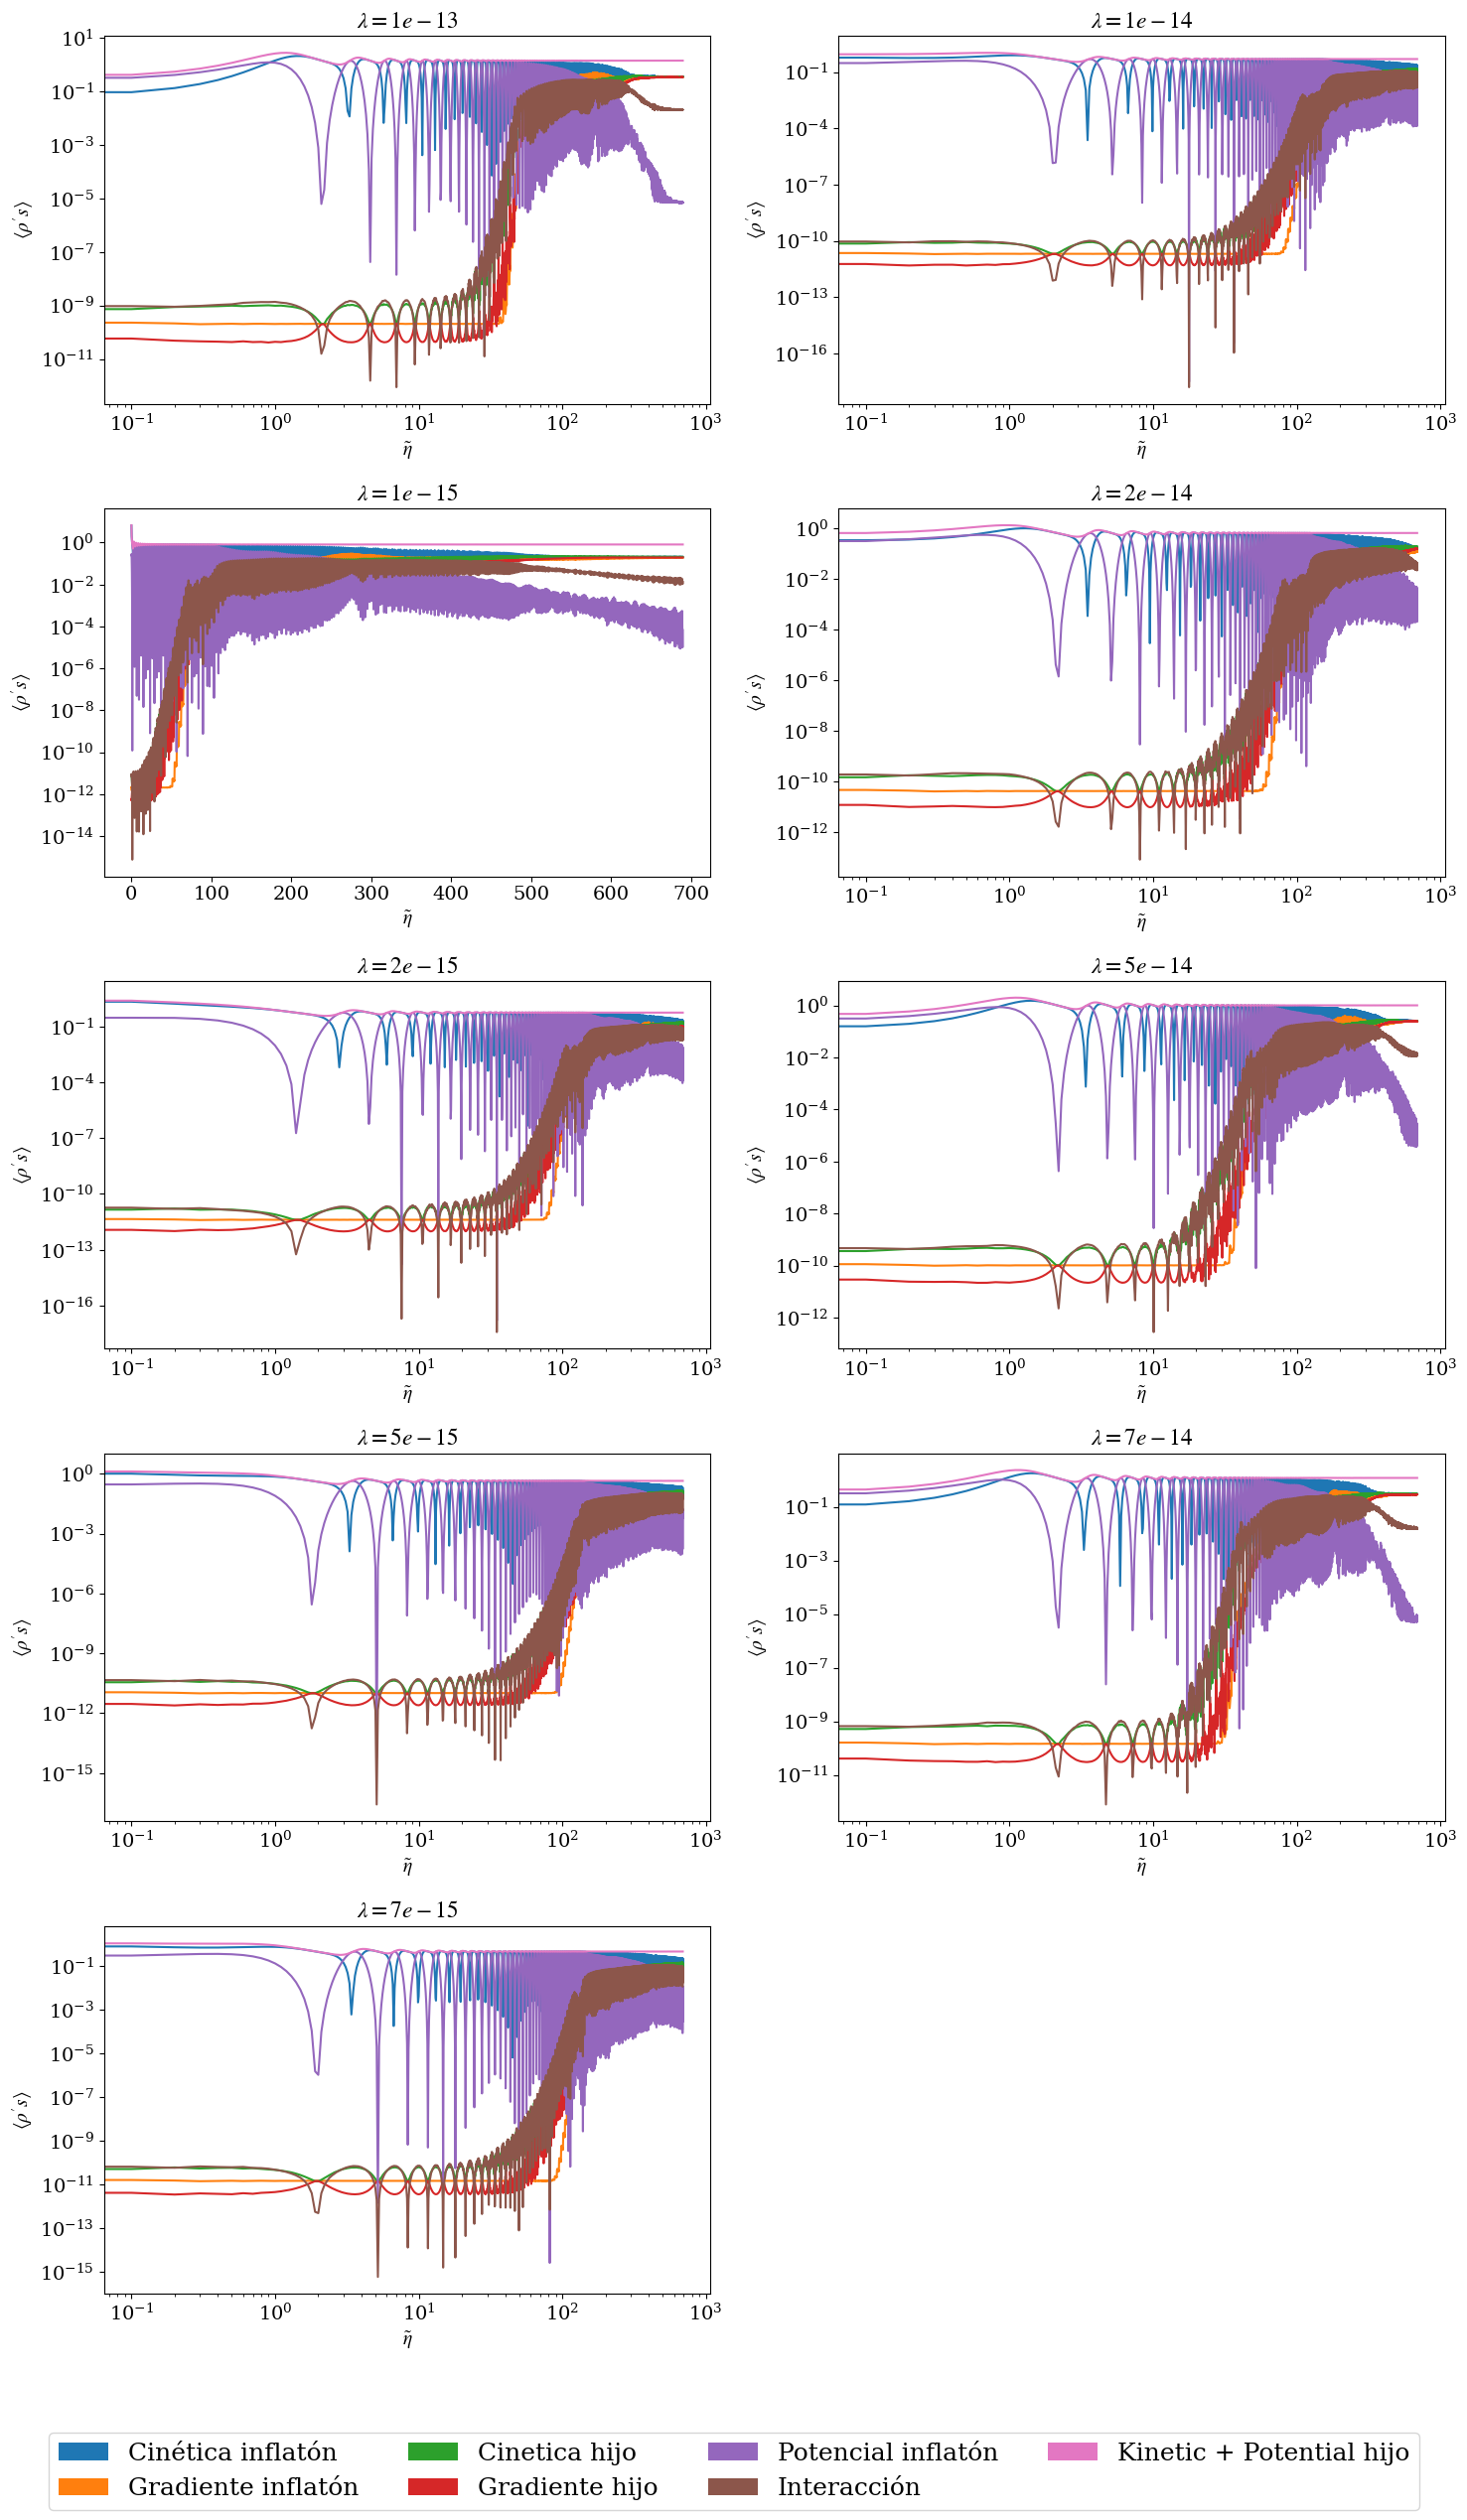

In [13]:
enDatl1e13 = np.loadtxt(dirl1e13 + "average_energies.txt")
enDatl1e14 = np.loadtxt(dirl1e14 + "average_energies.txt")
enDatl1e15 = np.loadtxt(dirl1e15 + "average_energies.txt")
enDatl2e14 = np.loadtxt(dirl2e14 + "average_energies.txt")
enDatl2e15 = np.loadtxt(dirl2e15 + "average_energies.txt")
enDatl5e14 = np.loadtxt(dirl5e14 + "average_energies.txt")
enDatl5e15 = np.loadtxt(dirl5e15 + "average_energies.txt")
enDatl7e14 = np.loadtxt(dirl7e14 + "average_energies.txt")
enDatl7e15 = np.loadtxt(dirl7e15 + "average_energies.txt")

nColumnsl1e13 = np.shape(enDatl1e13)[1]
nColumnsl1e14 = np.shape(enDatl1e14)[1]
nColumnsl1e15 = np.shape(enDatl1e15)[1]
nColumnsl2e14 = np.shape(enDatl2e14)[1]
nColumnsl2e15 = np.shape(enDatl2e15)[1]
nColumnsl5e14 = np.shape(enDatl5e14)[1]
nColumnsl5e15 = np.shape(enDatl5e15)[1]
nColumnsl7e14 = np.shape(enDatl7e14)[1]
nColumnsl7e15 = np.shape(enDatl7e15)[1]

# set explicitly different colors, so we know who is who
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]
label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]

fig = plt.figure(figsize=(15, 24))

plt.subplot(5, 2, 1)
for i in range(1,nColumnsl1e13):
    plt.plot(enDatl1e13[:,0], aDatl1e13[:,1]**4 * enDatl1e13[:,i], color = colors[i-1])
plt.title(r'$\lambda=1e-13$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 2)
for i in range(1,nColumnsl1e14):
    plt.plot(enDatl1e14[:,0], aDatl1e14[:,1]**4 * enDatl1e14[:,i], color = colors[i-1])
plt.title(r'$\lambda=1e-14$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 3)
for i in range(1,nColumnsl1e15):
    plt.plot(enDatl1e15[:,0], aDatl1e15[:,1]**4 * enDatl1e15[:,i], color = colors[i-1])
plt.title(r'$\lambda=1e-15$')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 4)
for i in range(1,nColumnsl2e14):
    plt.plot(enDatl2e14[:,0], aDatl2e14[:,1]**4 * enDatl2e14[:,i], color = colors[i-1])
plt.title(r'$\lambda=2e-14$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 5)
for i in range(1,nColumnsl2e15):
    plt.plot(enDatl2e15[:,0], aDatl2e15[:,1]**4 * enDatl2e15[:,i], color = colors[i-1])
plt.title(r'$\lambda=2e-15$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 6)
for i in range(1,nColumnsl5e14):
    plt.plot(enDatl5e14[:,0], aDatl5e14[:,1]**4 * enDatl5e14[:,i], color = colors[i-1])
plt.title(r'$\lambda=5e-14$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 7)
for i in range(1,nColumnsl5e15):
    plt.plot(enDatl5e15[:,0], aDatl5e15[:,1]**4 * enDatl5e15[:,i], color = colors[i-1])
plt.title(r'$\lambda=5e-15$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 8)
for i in range(1,nColumnsl7e14):
    plt.plot(enDatl7e14[:,0], aDatl7e14[:,1]**4 * enDatl7e14[:,i], color = colors[i-1])
plt.title(r'$\lambda=7e-14$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(5, 2, 9)
for i in range(1,nColumnsl7e15):
    plt.plot(enDatl7e15[:,0], aDatl7e15[:,1]**4 * enDatl7e15[:,i], color = colors[i-1])
plt.title(r'$\lambda=7e-15$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)


plt.tight_layout()
plt.show()
    

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [14]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

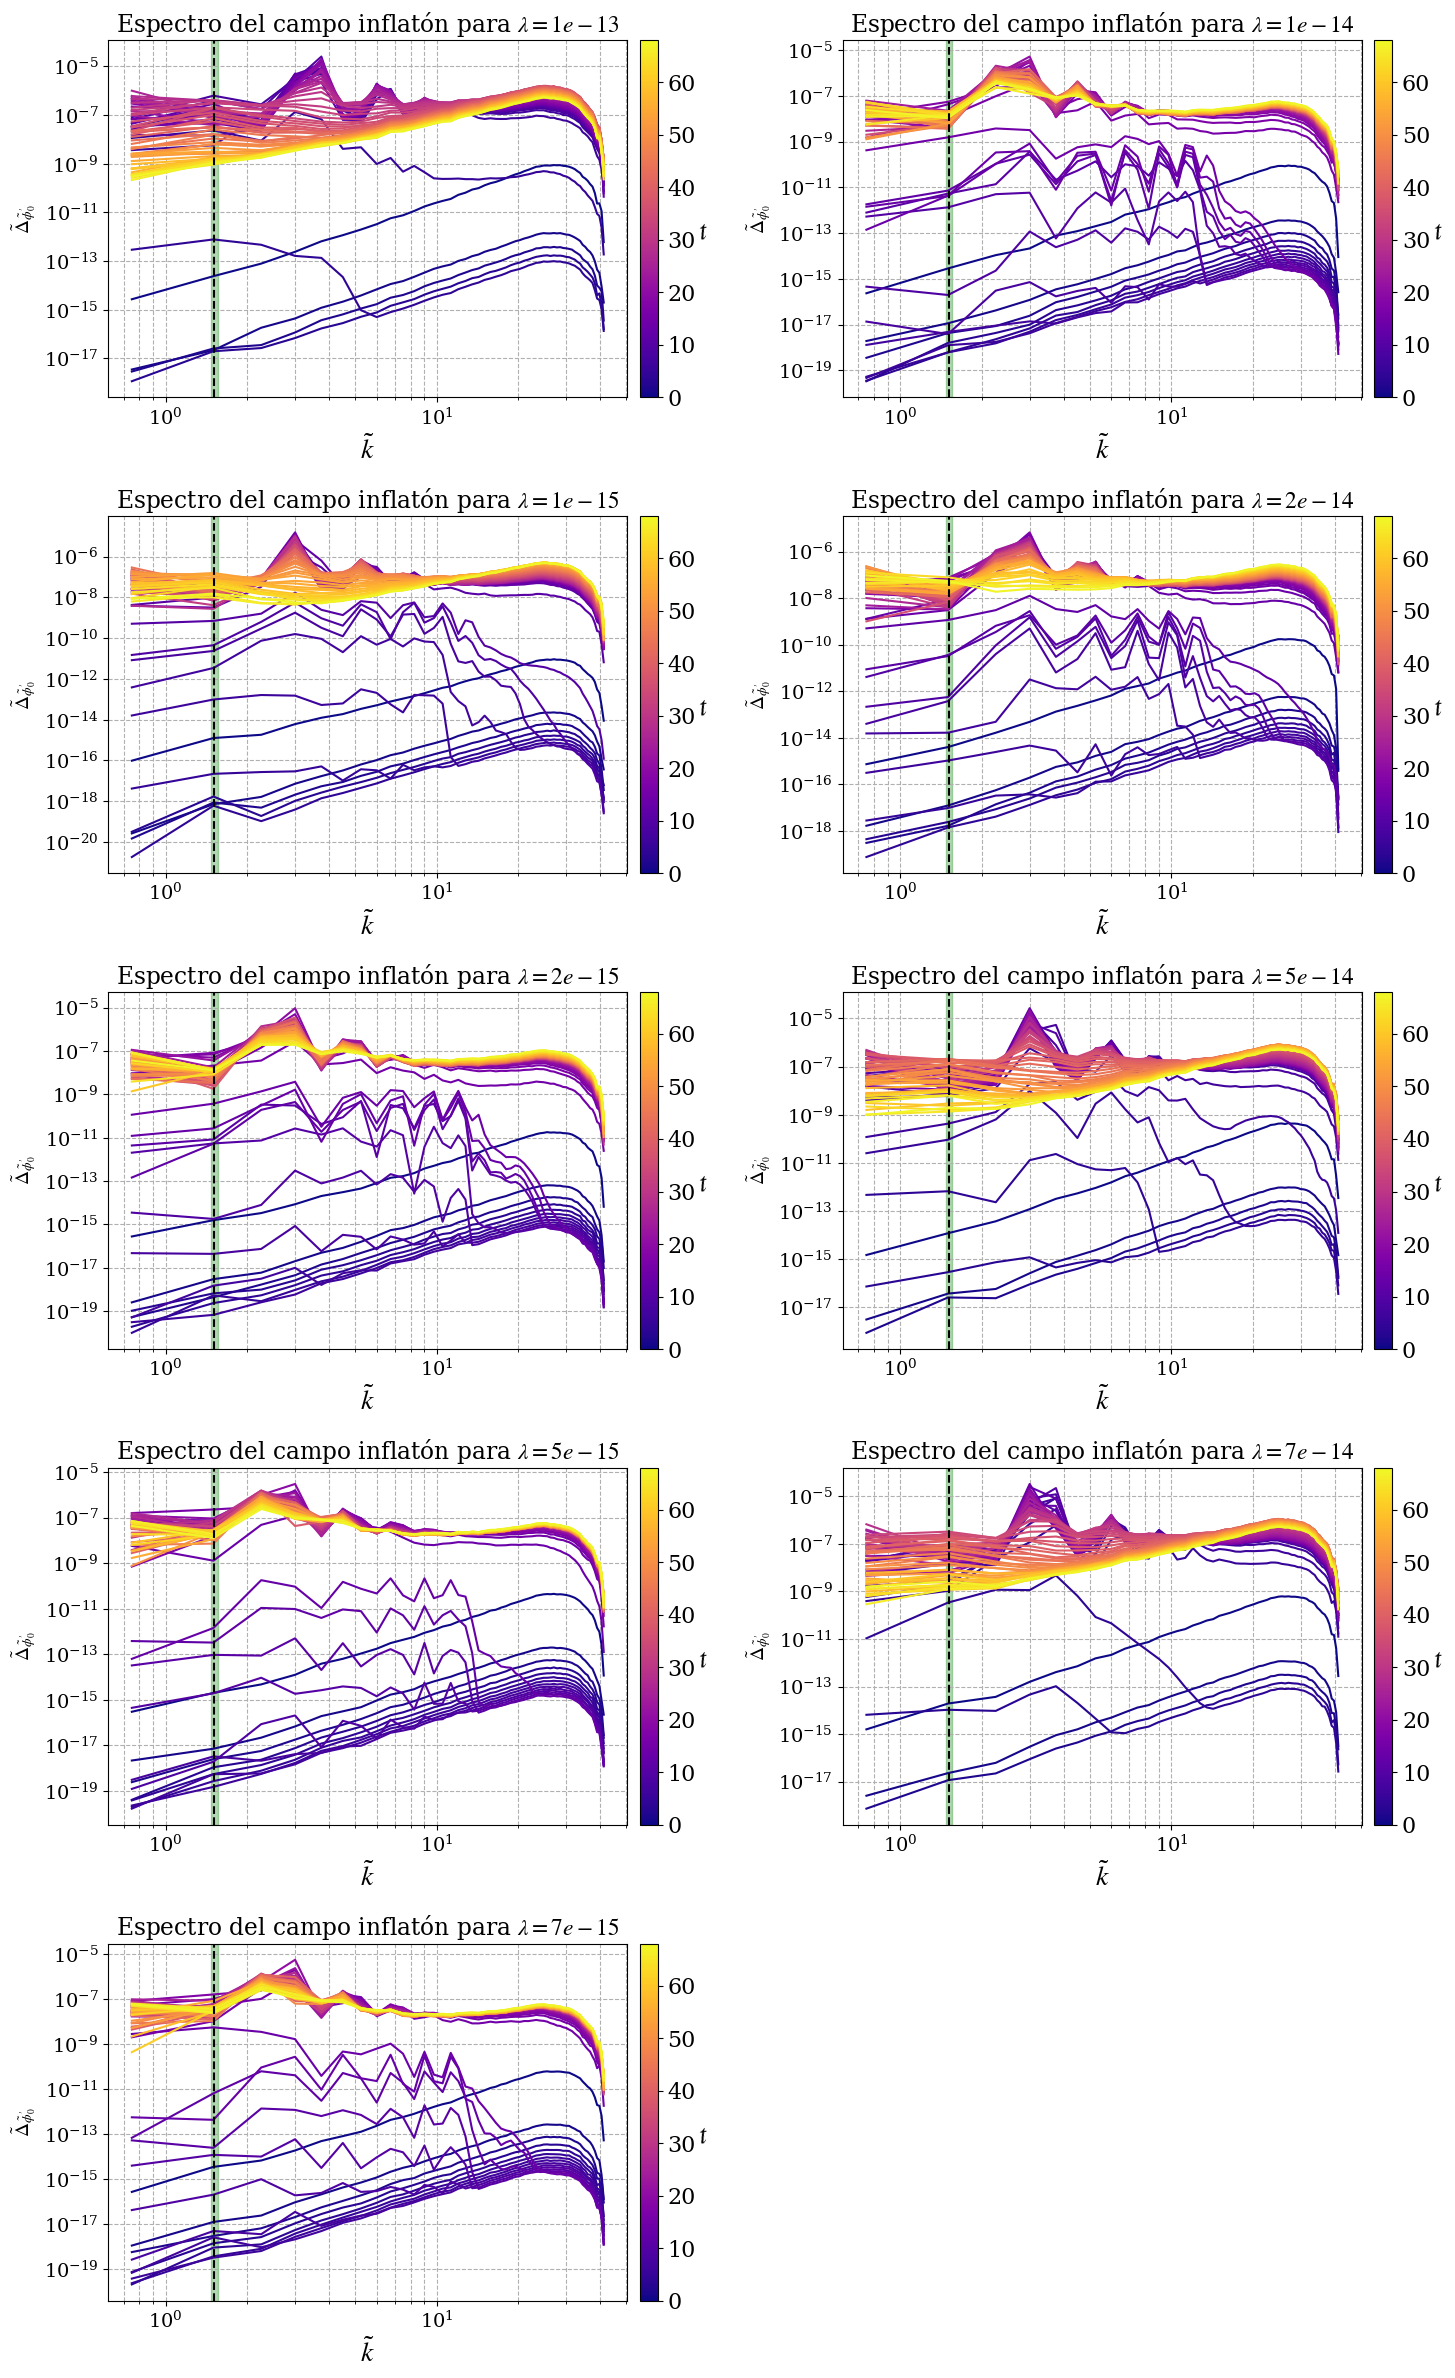

In [15]:
infSpl1e13, nBinsl1e13, nSpectral1e13 = load_spectrum(dirl1e13 + "spectra_scalar_0.txt")
infSpl1e14, nBinsl1e14, nSpectral1e14 = load_spectrum(dirl1e14 + "spectra_scalar_0.txt")
infSpl1e15, nBinsl1e15, nSpectral1e15 = load_spectrum(dirl1e15 + "spectra_scalar_0.txt")
infSpl2e14, nBinsl2e14, nSpectral2e14 = load_spectrum(dirl2e14 + "spectra_scalar_0.txt")
infSpl2e15, nBinsl2e15, nSpectral2e15 = load_spectrum(dirl2e15 + "spectra_scalar_0.txt")
infSpl5e14, nBinsl5e14, nSpectral5e14 = load_spectrum(dirl5e14 + "spectra_scalar_0.txt")
infSpl5e15, nBinsl5e15, nSpectral5e15 = load_spectrum(dirl5e15 + "spectra_scalar_0.txt")
infSpl7e14, nBinsl7e14, nSpectral7e14 = load_spectrum(dirl7e14 + "spectra_scalar_0.txt")
infSpl7e15, nBinsl7e15, nSpectral7e15 = load_spectrum(dirl7e15 + "spectra_scalar_0.txt")

plt.figure(figsize=(15, 24))

plt.subplot(5, 2, 1)
plot_spectrum(infSpl1e13, 2,  nBinsl1e13, nSpectral1e13)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 1e-13$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 2)
plot_spectrum(infSpl1e14, 2,  nBinsl1e14, nSpectral1e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 1e-14$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 3)
plot_spectrum(infSpl1e15, 2,  nBinsl1e15, nSpectral1e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 1e-15$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 4)
plot_spectrum(infSpl2e14, 2,  nBinsl2e14, nSpectral2e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 2e-14$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 5)
plot_spectrum(infSpl2e15, 2,  nBinsl2e15, nSpectral2e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 2e-15$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 6)
plot_spectrum(infSpl5e14, 2,  nBinsl5e14, nSpectral5e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 5e-14$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 7)
plot_spectrum(infSpl5e15, 2,  nBinsl5e15, nSpectral5e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 5e-15$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 8)
plot_spectrum(infSpl7e14, 2,  nBinsl7e14, nSpectral7e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 7e-14$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.subplot(5, 2, 9)
plot_spectrum(infSpl7e15, 2,  nBinsl7e15, nSpectral7e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\lambda = 7e-15$')
plt.axvline(k_maxq3, color='k', linestyle='--')
plt.axvspan(k_deltaq3[-1], k_deltaq3[0], color='green', alpha=0.3)

plt.tight_layout()
plt.show()

## Daughter field

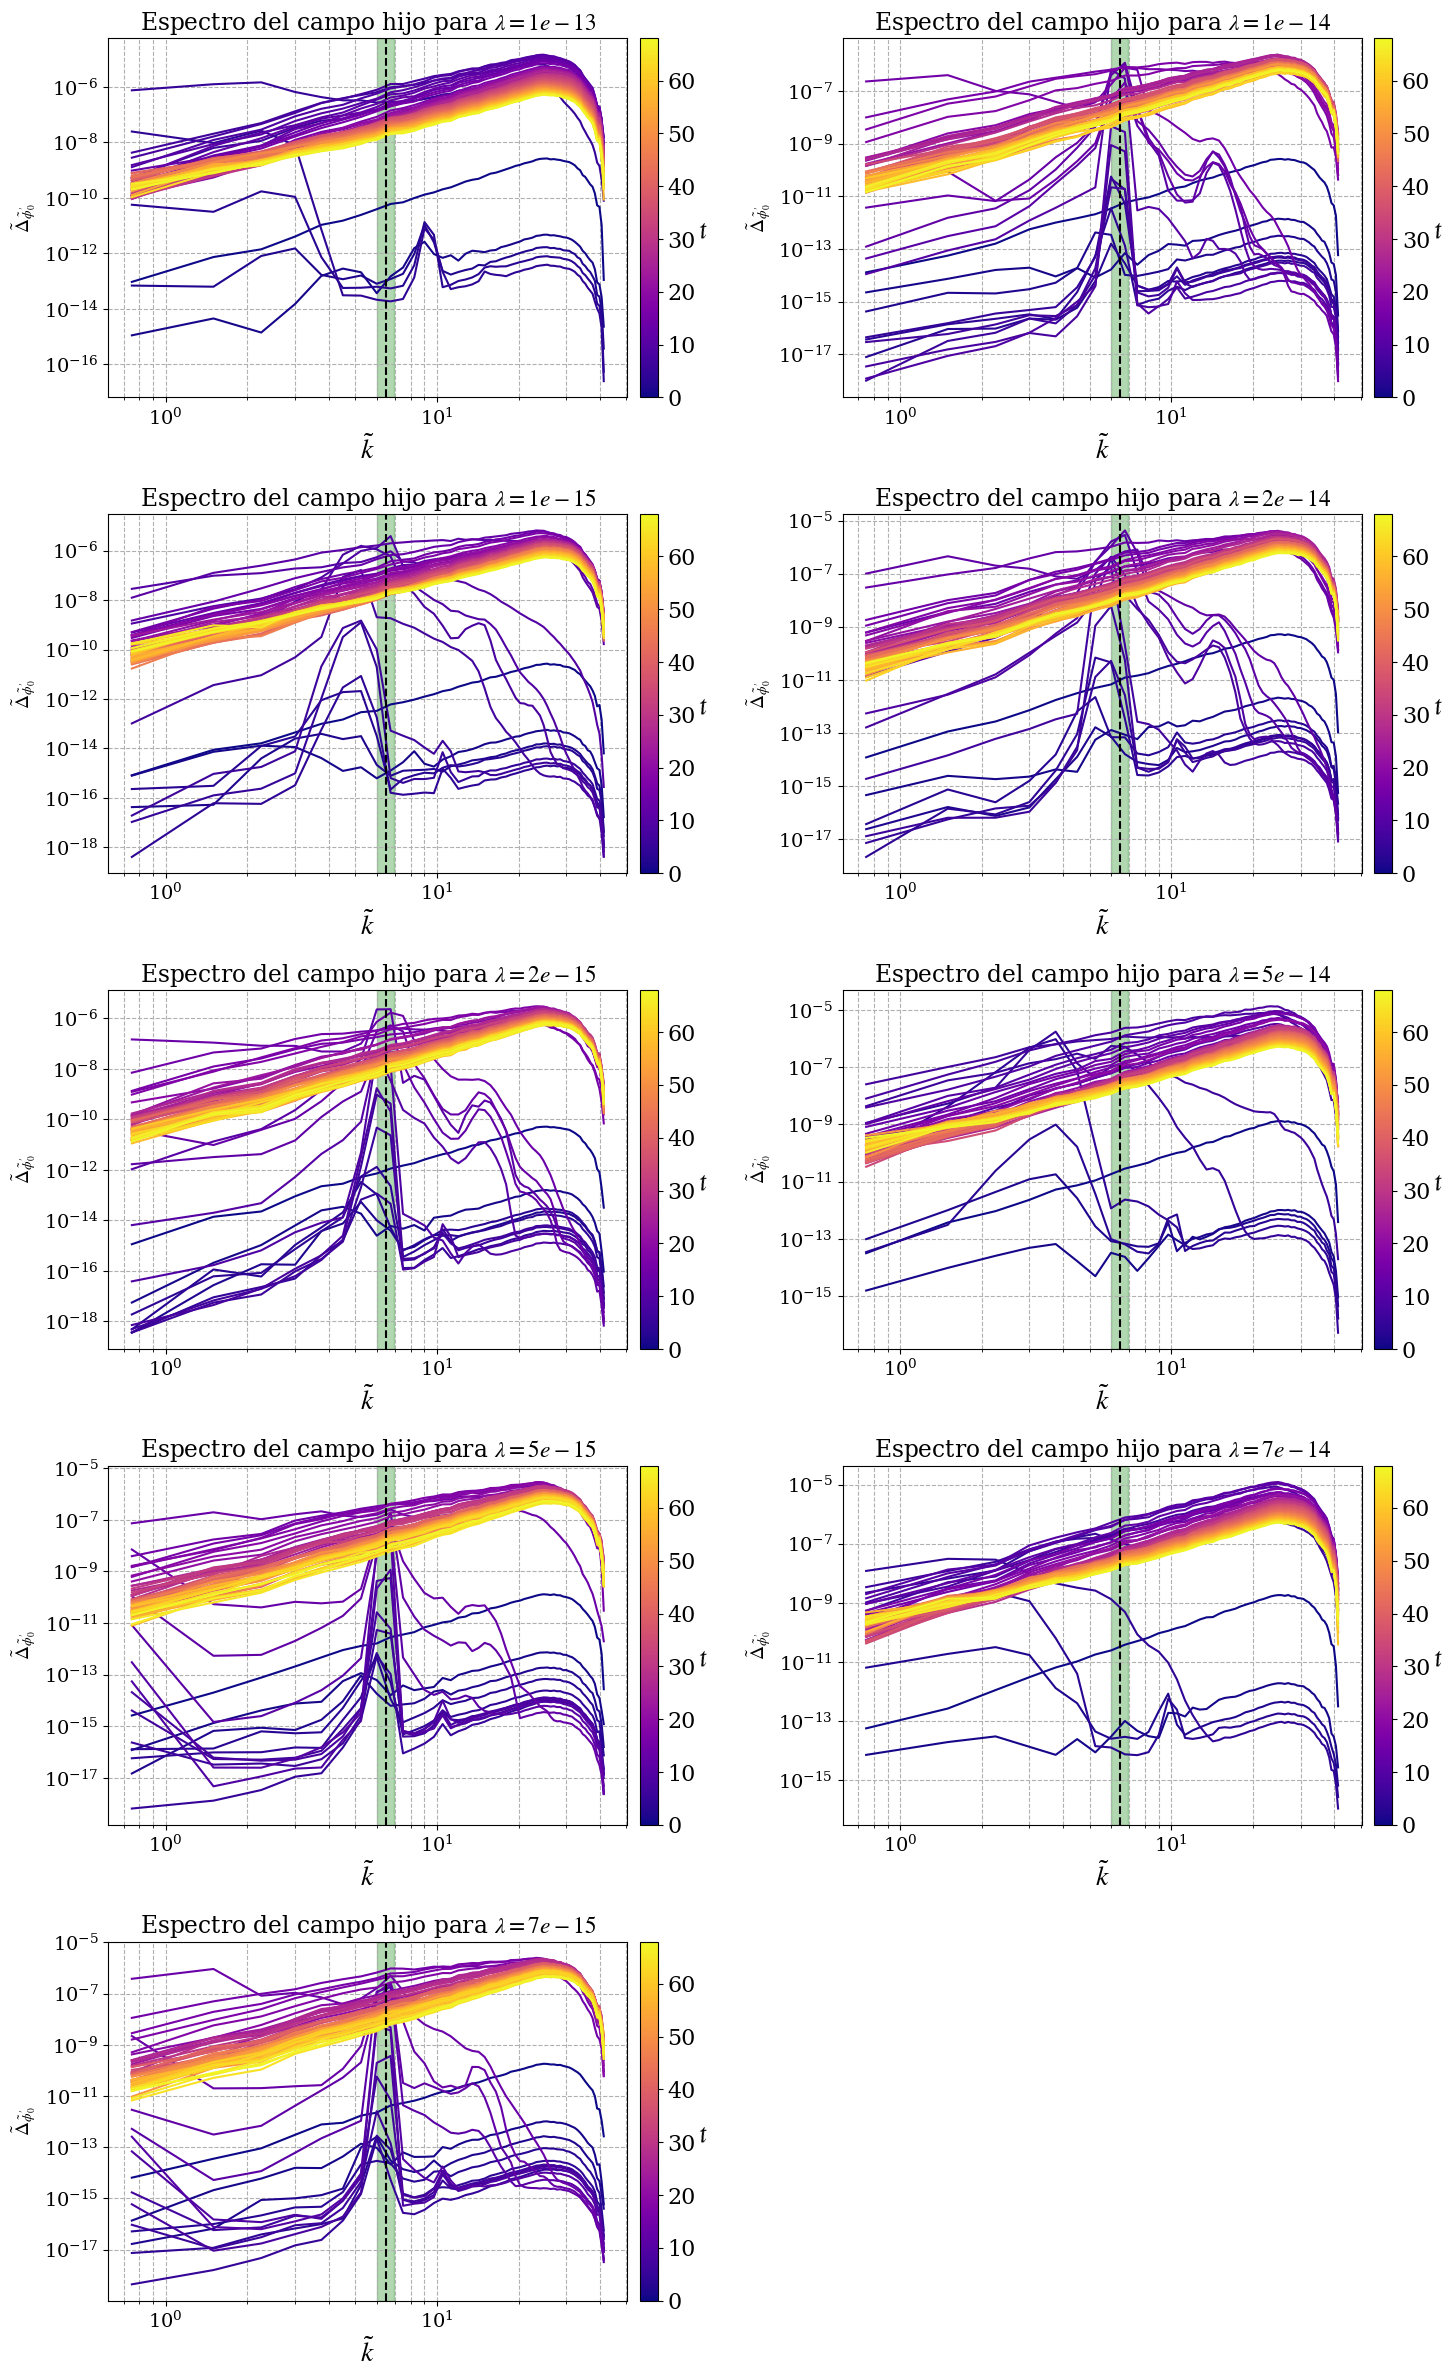

In [16]:
infSpl1e13, nBinsl1e13, nSpectral1e13 = load_spectrum(dirl1e13 + "spectra_scalar_1.txt")
infSpl1e14, nBinsl1e14, nSpectral1e14 = load_spectrum(dirl1e14 + "spectra_scalar_1.txt")
infSpl1e15, nBinsl1e15, nSpectral1e15 = load_spectrum(dirl1e15 + "spectra_scalar_1.txt")
infSpl2e14, nBinsl2e14, nSpectral2e14 = load_spectrum(dirl2e14 + "spectra_scalar_1.txt")
infSpl2e15, nBinsl2e15, nSpectral2e15 = load_spectrum(dirl2e15 + "spectra_scalar_1.txt")
infSpl5e14, nBinsl5e14, nSpectral5e14 = load_spectrum(dirl5e14 + "spectra_scalar_1.txt")
infSpl5e15, nBinsl5e15, nSpectral5e15 = load_spectrum(dirl5e15 + "spectra_scalar_1.txt")
infSpl7e14, nBinsl7e14, nSpectral7e14 = load_spectrum(dirl7e14 + "spectra_scalar_1.txt")
infSpl7e15, nBinsl7e15, nSpectral7e15 = load_spectrum(dirl7e15 + "spectra_scalar_1.txt")

plt.figure(figsize=(15, 24))

plt.subplot(5, 2, 1)
plot_spectrum(infSpl1e13, 2,  nBinsl1e13, nSpectral1e13)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 1e-13$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 2)
plot_spectrum(infSpl1e14, 2,  nBinsl1e14, nSpectral1e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 1e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 3)
plot_spectrum(infSpl1e15, 2,  nBinsl1e15, nSpectral1e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 1e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 4)
plot_spectrum(infSpl2e14, 2,  nBinsl2e14, nSpectral2e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 2e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 5)
plot_spectrum(infSpl2e15, 2,  nBinsl2e15, nSpectral2e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 2e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 6)
plot_spectrum(infSpl5e14, 2,  nBinsl5e14, nSpectral5e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 5e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 7)
plot_spectrum(infSpl5e15, 2,  nBinsl5e15, nSpectral5e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 5e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 8)
plot_spectrum(infSpl7e14, 2,  nBinsl7e14, nSpectral7e14)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 7e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 9)
plot_spectrum(infSpl7e15, 2,  nBinsl7e15, nSpectral7e15)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\lambda = 7e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.tight_layout()
plt.show()

# GWs

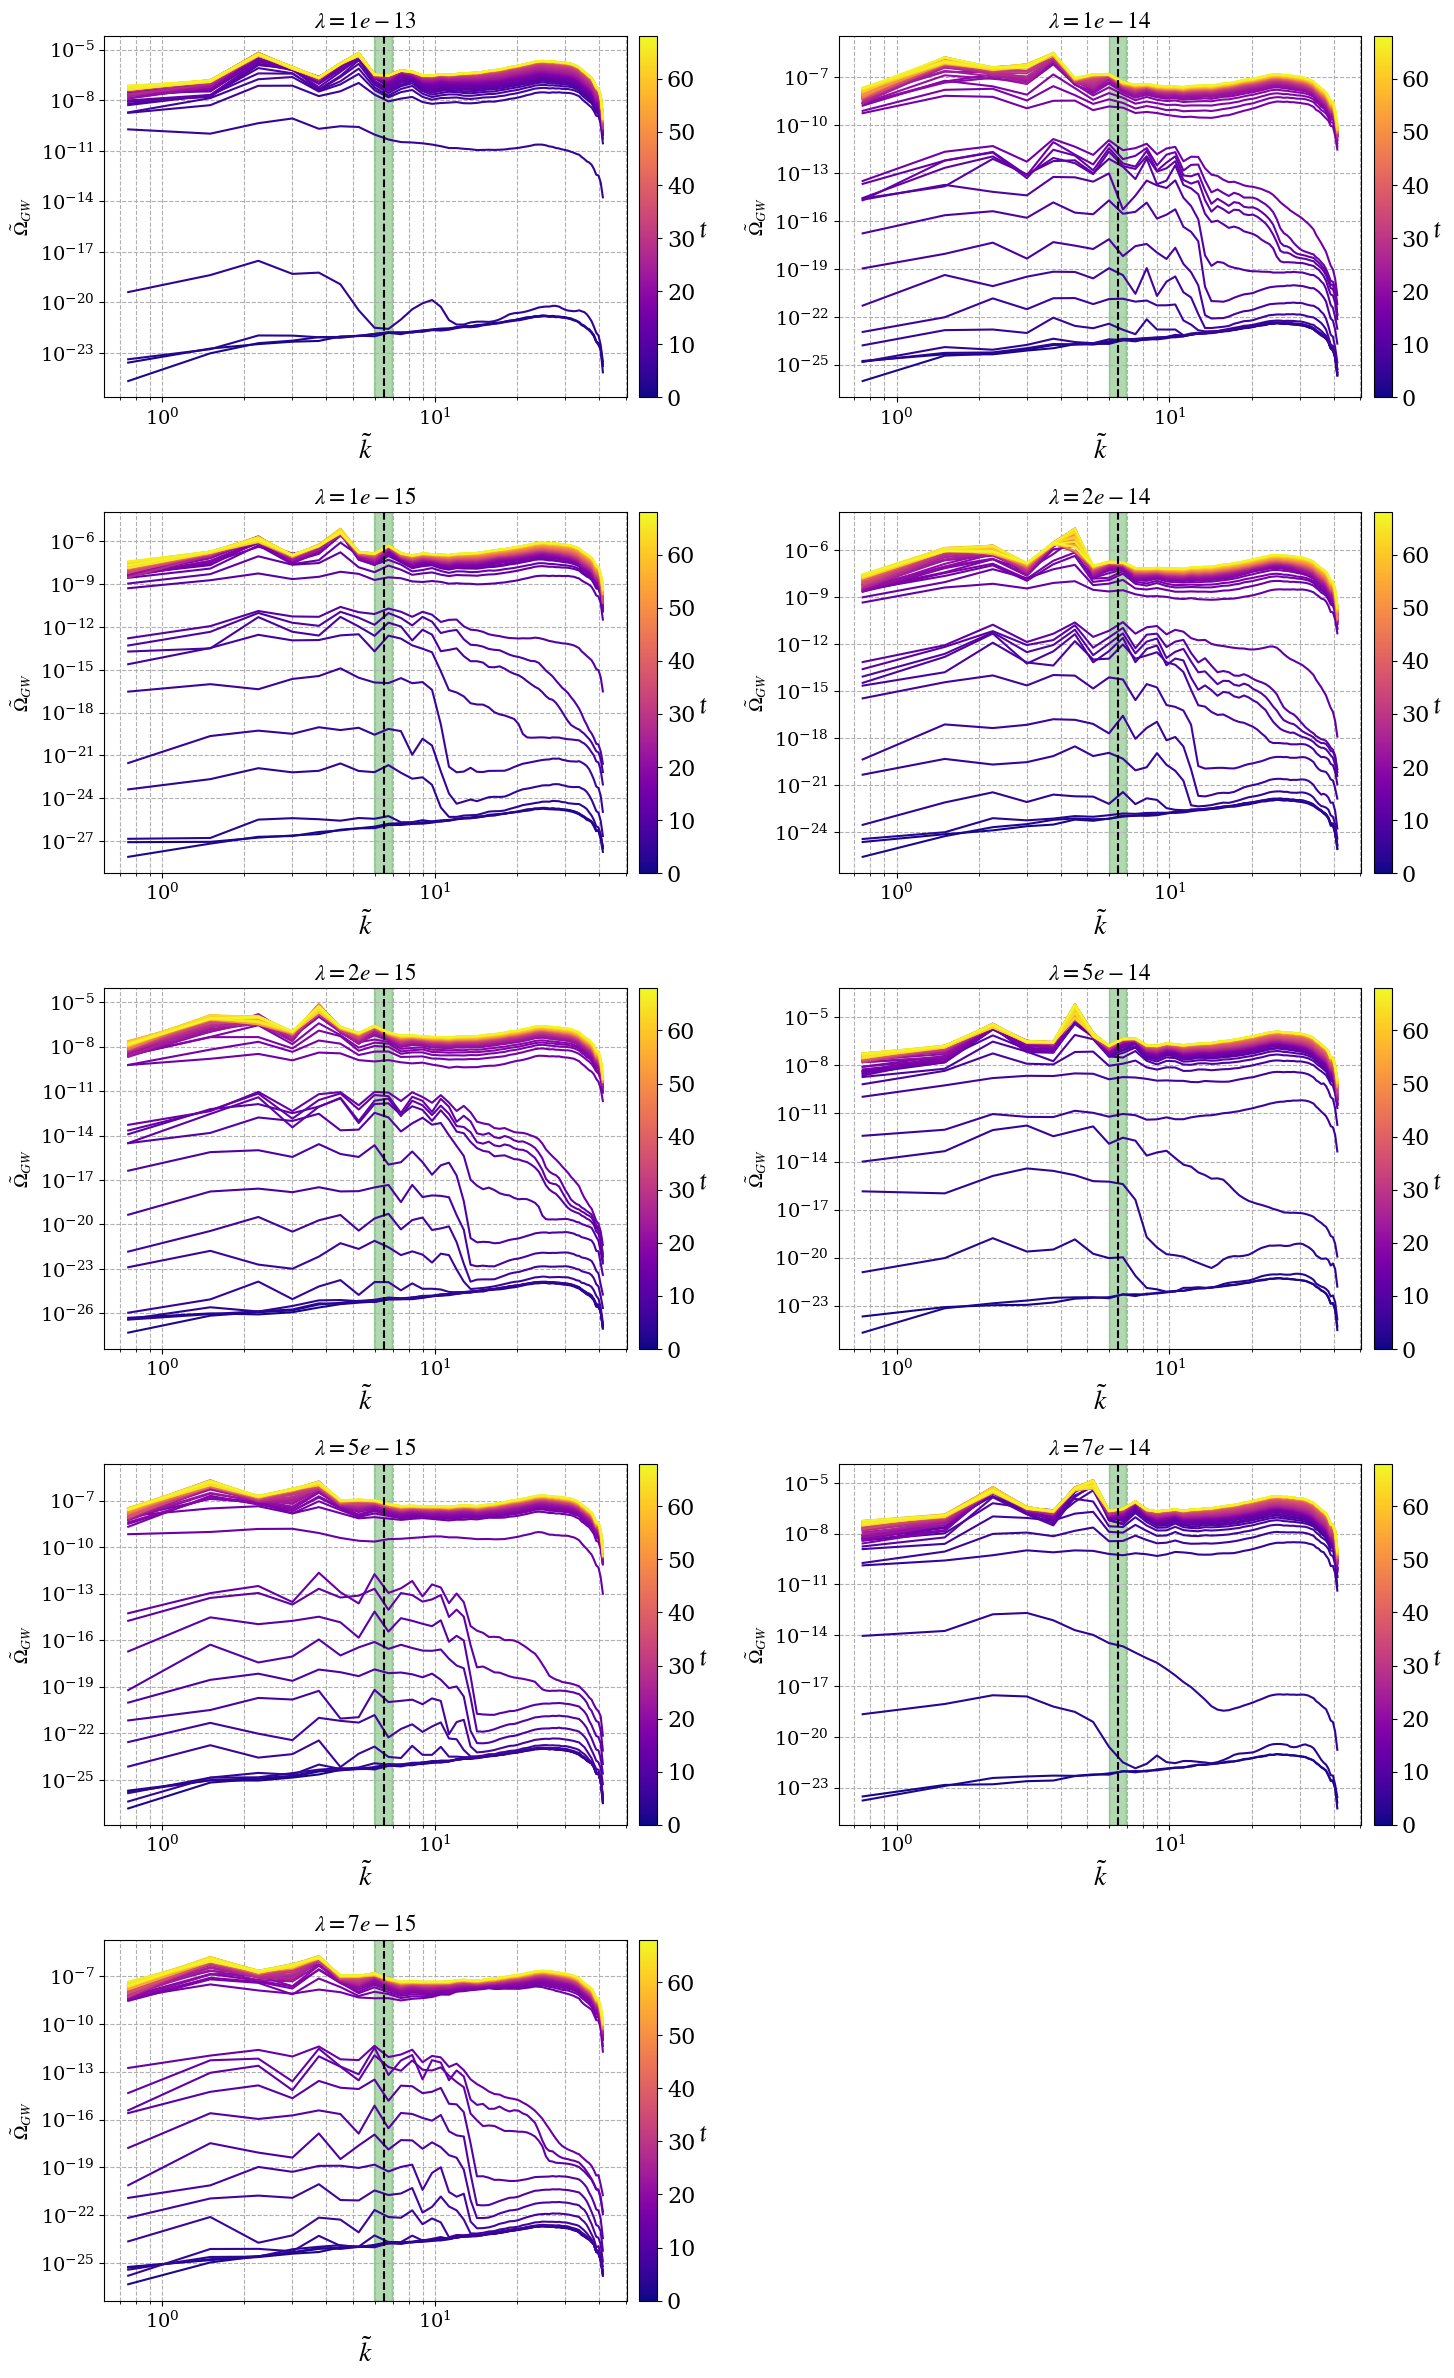

In [17]:
gwSpl1e13, nBinsl1e13, nSpectral1e13 = load_spectrum(dirl1e13 + "spectra_gws.txt")
gwSpl1e14, nBinsl1e14, nSpectral1e14 = load_spectrum(dirl1e14 + "spectra_gws.txt")
gwSpl1e15, nBinsl1e15, nSpectral1e15 = load_spectrum(dirl1e15 + "spectra_gws.txt")
gwSpl2e14, nBinsl2e14, nSpectral2e14 = load_spectrum(dirl2e14 + "spectra_gws.txt")
gwSpl2e15, nBinsl2e15, nSpectral2e15 = load_spectrum(dirl2e15 + "spectra_gws.txt")
gwSpl5e14, nBinsl5e14, nSpectral5e14 = load_spectrum(dirl5e14 + "spectra_gws.txt")
gwSpl5e15, nBinsl5e15, nSpectral5e15 = load_spectrum(dirl5e15 + "spectra_gws.txt")
gwSpl7e14, nBinsl7e14, nSpectral7e14 = load_spectrum(dirl7e14 + "spectra_gws.txt")
gwSpl7e15, nBinsl7e15, nSpectral7e15 = load_spectrum(dirl7e15 + "spectra_gws.txt")

plt.figure(figsize=(15, 24))

plt.subplot(5, 2, 1)
plot_spectrum(gwSpl1e13, 1,  nBinsl1e13, nSpectral1e13)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 1e-13$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 2)
plot_spectrum(gwSpl1e14, 1,  nBinsl1e14, nSpectral1e14)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 1e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 3)
plot_spectrum(gwSpl1e15, 1,  nBinsl1e15, nSpectral1e15)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 1e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 4)
plot_spectrum(gwSpl2e14, 1,  nBinsl2e14, nSpectral2e14)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 2e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 5)
plot_spectrum(gwSpl2e15, 1,  nBinsl2e15, nSpectral2e15)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 2e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 6)
plot_spectrum(gwSpl5e14, 1,  nBinsl5e14, nSpectral5e14)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 5e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 7)
plot_spectrum(gwSpl5e15, 1,  nBinsl5e15, nSpectral5e15)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 5e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 8)
plot_spectrum(gwSpl7e14, 1,  nBinsl7e14, nSpectral7e14)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 7e-14$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.subplot(5, 2, 9)
plot_spectrum(gwSpl7e15, 1,  nBinsl7e15, nSpectral7e15)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda = 7e-15$')
plt.axvline(k_maxq, color='k', linestyle='--')
plt.axvspan(k_deltaq[-1], k_deltaq[0], color='green', alpha=0.3)

plt.tight_layout()
plt.show()